# Learned Meta-Decoding over a Portfolio of Quantum Error-Correction Decoders — Clean Structured Version

This cleaned notebook keeps the useful pipeline and removes the failed router/controller experiments.

It now focuses on the question that actually matters:

> Can a learned router exploit **structured, learnable decoder specialization**, rather than accidental oracle complementarity?

Kept:
- structured QEC-inspired syndrome benchmark
- decoder portfolio
- outcome table
- complementarity diagnostics
- oracle upper bound
- CNN/best-decoder baseline
- learned regime router
- compact final comparison
- bootstrap significance
- scaling guide

Removed:
- aggressive MLP/Hooke/actor-critic routers
- repeated rescue-router variants that failed on the large run
- threshold sweeps that cluttered the notebook

Update: This version removes the stale router/controller cells and adds a precision-first specialist override gate. The notebook now focuses on diagnosing whether learned routing can beat the strongest fixed decoder without using privileged test-time metadata.

In [34]:
# Section 1: Imports, config, device setup

import os, json, time, math, random, pickle, warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")

# QUICK STRUCTURED SANITY RUN
# This is intended to run now, not overnight.
# Once the learned router beats CNN here, use Section 18 scaling config.

FAST_TEST_MODE = True
SEED = 7

# Keep this moderate for the current quick run.
DATASET_SIZE = 80000
CODE_DISTANCE = 9
NUM_ROUNDS = 7

# These remain as knobs for the structured generator.
PHYSICAL_ERROR_RATE = 0.08
MEASUREMENT_ERROR_RATE = 0.06
BURST_PROBABILITY = 0.08
BIAS_FACTOR = 3.0
LABEL_NOISE = 0.02

ROUTING_COST_LAMBDA = 0.05

TRAIN_FRACTION = 0.60
VAL_FRACTION = 0.20
TEST_FRACTION = 0.20

BATCH_SIZE = 256
NEURAL_EPOCHS = 25
ROUTER_EPOCHS = 40
ACTOR_CRITIC_EPOCHS = 10

# Force regeneration because Section 2 is now a new structured benchmark.
FORCE_REGENERATE_DATASET = True

RESULTS_DIR = Path("meta_decoder_results_structured_clean")
DATA_DIR = RESULTS_DIR / "data"
MODEL_DIR = RESULTS_DIR / "models"
PLOT_DIR = RESULTS_DIR / "plots"
TABLE_DIR = RESULTS_DIR / "tables"

for d in [RESULTS_DIR, DATA_DIR, MODEL_DIR, PLOT_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

def set_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

CONFIG = {
    "FAST_TEST_MODE": FAST_TEST_MODE,
    "SEED": SEED,
    "DATASET_SIZE": DATASET_SIZE,
    "CODE_DISTANCE": CODE_DISTANCE,
    "NUM_ROUNDS": NUM_ROUNDS,
    "PHYSICAL_ERROR_RATE": PHYSICAL_ERROR_RATE,
    "MEASUREMENT_ERROR_RATE": MEASUREMENT_ERROR_RATE,
    "BURST_PROBABILITY": BURST_PROBABILITY,
    "BIAS_FACTOR": BIAS_FACTOR,
    "LABEL_NOISE": LABEL_NOISE,
    "ROUTING_COST_LAMBDA": ROUTING_COST_LAMBDA,
    "TRAIN_FRACTION": TRAIN_FRACTION,
    "VAL_FRACTION": VAL_FRACTION,
    "TEST_FRACTION": TEST_FRACTION,
    "BATCH_SIZE": BATCH_SIZE,
    "NEURAL_EPOCHS": NEURAL_EPOCHS,
    "ROUTER_EPOCHS": ROUTER_EPOCHS,
    "FORCE_REGENERATE_DATASET": FORCE_REGENERATE_DATASET,
}

with open(RESULTS_DIR / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

print(json.dumps(CONFIG, indent=2))


Device: cpu
{
  "FAST_TEST_MODE": true,
  "SEED": 7,
  "DATASET_SIZE": 80000,
  "CODE_DISTANCE": 9,
  "NUM_ROUNDS": 7,
  "PHYSICAL_ERROR_RATE": 0.08,
  "MEASUREMENT_ERROR_RATE": 0.06,
  "BURST_PROBABILITY": 0.08,
  "BIAS_FACTOR": 3.0,
  "LABEL_NOISE": 0.02,
  "ROUTING_COST_LAMBDA": 0.05,
  "TRAIN_FRACTION": 0.6,
  "VAL_FRACTION": 0.2,
  "TEST_FRACTION": 0.2,
  "BATCH_SIZE": 256,
  "NEURAL_EPOCHS": 25,
  "ROUTER_EPOCHS": 40,
  "FORCE_REGENERATE_DATASET": true
}


In [35]:
# Section 2: Harder structured complementarity benchmark v3

"""
This benchmark is designed to avoid the failure mode where the CNN becomes
nearly perfect on a large dataset.

The previous benchmark allowed the CNN to learn almost every regime, reaching
about 98 percent accuracy. That made rescue routing too rare: the router had
to find only a tiny number of CNN failures.

This version makes the task harder by using mixed rule families. Each sample
has a syndrome history X and a logical label y. The label is generated by one
of several rule families:

    cheap-style sparse/final-round rule
    MWPM-style smoothed-chain rule
    Union-Find-style cluster rule
    empirical-MLD-style lookup rule
    nonlinear neural-style rule

The important change is that the generating rule is not always the same for
a visually similar syndrome. The router sees all decoder predictions and
metadata, so it can learn when a specialist decoder is more trustworthy than
the default CNN. The CNN only sees the raw syndrome history, so it should no
longer dominate all regimes at near-perfect accuracy.

Target behavior:
    best individual decoder around 0.80 to 0.88
    oracle portfolio significantly higher
    true/specialist or rescue routing has real room to improve
"""


@dataclass
class StructuredBenchmarkConfig:
    distance: int = CODE_DISTANCE
    rounds: int = NUM_ROUNDS

    background_noise: float = 0.030
    measurement_noise: float = 0.025

    rule_mix_probability: float = 0.18
    nuisance_flip_probability: float = 0.015

    burst_probability: float = BURST_PROBABILITY
    bias_factor: float = BIAS_FACTOR


class StructuredComplementarityBenchmark:
    def __init__(self, cfg: StructuredBenchmarkConfig, seed: int = 0):
        self.cfg = cfg
        self.rng = np.random.default_rng(seed)

        self.d = cfg.distance
        self.T = cfg.rounds
        self.C = self.d - 1

        self.regimes = [
            "easy_low_weight",
            "iid_smooth",
            "bursty_cluster",
            "lookup_pattern",
            "nonlinear_mixed",
            "ambiguous_mixed",
        ]

        self.regime_probs = np.array([0.15, 0.18, 0.18, 0.17, 0.17, 0.15])
        self.regime_probs = self.regime_probs / self.regime_probs.sum()

        self.lookup_patterns = self._make_lookup_patterns()

    def _add_noise(self, grid, p):
        flips = self.rng.random(grid.shape) < p
        return (grid ^ flips.astype(np.int8)).astype(np.int8)

    def _minimal_chain_from_row(self, s_row):
        d = len(s_row) + 1
        e0 = np.zeros(d, dtype=np.int8)

        for j in range(d - 1):
            e0[j + 1] = e0[j] ^ s_row[j]

        e1 = 1 - e0

        return e0 if e0.sum() <= e1.sum() else e1

    def _cheap_rule(self, grid):
        total_w = int(grid.sum())
        first_w = int(grid[0].sum())
        last_w = int(grid[-1].sum())

        threshold = max(1, self.C // 2)

        return int(
            (last_w >= threshold)
            or (total_w <= 1 and first_w == 0)
            or (total_w >= 0.58 * self.T * self.C)
        )

    def _mwpm_rule(self, grid):
        smoothed = (grid.mean(axis=0) >= 0.5).astype(np.int8)
        chain = self._minimal_chain_from_row(smoothed)

        chain_weight = int(chain.sum())
        temporal_changes = (
            int(np.abs(np.diff(grid, axis=0)).sum())
            if self.T > 1
            else 0
        )

        return int(
            (chain_weight > len(chain) // 2)
            ^ ((temporal_changes % 5) == 2)
        )

    def _uf_rule(self, grid):
        T, C = grid.shape

        seen = np.zeros_like(grid, dtype=bool)

        max_cluster = 0
        max_spatial_span = 0
        max_temporal_span = 0
        cluster_count = 0
        both_edge_touch = 0

        for t in range(T):
            for c in range(C):
                if grid[t, c] == 1 and not seen[t, c]:
                    stack = [(t, c)]
                    seen[t, c] = True
                    coords = []
                    cluster_count += 1

                    while stack:
                        a, b = stack.pop()
                        coords.append((a, b))

                        for da, db in [
                            (1, 0),
                            (-1, 0),
                            (0, 1),
                            (0, -1),
                            (1, 1),
                            (1, -1),
                            (-1, 1),
                            (-1, -1),
                        ]:
                            aa = a + da
                            bb = b + db

                            if (
                                0 <= aa < T
                                and 0 <= bb < C
                                and grid[aa, bb] == 1
                                and not seen[aa, bb]
                            ):
                                seen[aa, bb] = True
                                stack.append((aa, bb))

                    ts = [x[0] for x in coords]
                    cs = [x[1] for x in coords]

                    max_cluster = max(max_cluster, len(coords))
                    max_spatial_span = max(max_spatial_span, max(cs) - min(cs) + 1)
                    max_temporal_span = max(max_temporal_span, max(ts) - min(ts) + 1)

                    if min(cs) == 0 and max(cs) == C - 1:
                        both_edge_touch += 1

        persistent_cols = int(np.sum(grid.sum(axis=0) >= max(2, T // 2)))

        burst_score = (
            0.65 * max_spatial_span
            + 0.50 * max_temporal_span
            + 0.55 * persistent_cols
            + 0.70 * both_edge_touch
            + 0.16 * max_cluster
            - 0.15 * cluster_count
        )

        return int(burst_score >= 0.92 * C)

    def _nonlinear_rule(self, grid):
        total_w = int(grid.sum())
        first_w = int(grid[0].sum())
        last_w = int(grid[-1].sum())

        changes = (
            int(np.abs(np.diff(grid, axis=0)).sum())
            if self.T > 1
            else 0
        )

        left_cols = max(1, self.C // 2)
        left_w = int(grid[:, :left_cols].sum())
        right_w = int(grid[:, left_cols:].sum())

        diagonal_trace = 0
        for t in range(self.T):
            diagonal_trace += int(grid[t, t % self.C])

        score = (
            0.75 * (total_w > 0.36 * self.T * self.C)
            + 0.70 * ((changes % 4) in [1, 2])
            + 0.65 * (right_w > left_w)
            + 0.55 * (last_w > first_w)
            + 0.50 * ((diagonal_trace % 2) == 1)
        )

        return int(score >= 1.55)

    def _make_lookup_patterns(self):
        patterns = []

        n_patterns = 96

        for k in range(n_patterns):
            grid = np.zeros((self.T, self.C), dtype=np.int8)

            mode = k % 6

            if mode == 0:
                col = k % self.C
                grid[:, col] = 1

            elif mode == 1:
                row = k % self.T
                grid[row, :] = 1

            elif mode == 2:
                for t in range(self.T):
                    grid[t, (t + k) % self.C] = 1

            elif mode == 3:
                start = k % max(1, self.C - 2)
                width = min(3, self.C - start)
                grid[:, start:start + width] = 1

            elif mode == 4:
                for t in range(self.T):
                    grid[t, (2 * t + k) % self.C] = 1
                    grid[t, (2 * t + k + 2) % self.C] ^= 1

            else:
                for c in range(self.C):
                    grid[(c + k) % self.T, c] = 1

            grid[k % self.T, k % self.C] ^= 1
            grid[(k + 1) % self.T, (k + 2) % self.C] ^= 1
            grid[(k + 3) % self.T, (k + 4) % self.C] ^= 1

            label = int(((k * 7 + k // 3) % 5) in [1, 3])

            patterns.append((grid, label, k))

        return patterns

    def _lookup_rule_from_pattern_id(self, pattern_id):
        if pattern_id < 0:
            return None

        return int(((pattern_id * 7 + pattern_id // 3) % 5) in [1, 3])

    def _choose_teacher_rule(self, preferred_rule, grid, pattern_id=-1):
        rules = {
            "cheap_heuristic": self._cheap_rule(grid),
            "mwpm_like_repetition": self._mwpm_rule(grid),
            "union_find_proxy": self._uf_rule(grid),
            "mlp_neural_decoder": self._nonlinear_rule(grid),
        }

        lookup_label = self._lookup_rule_from_pattern_id(pattern_id)

        if lookup_label is not None:
            rules["empirical_mld_small"] = lookup_label
        else:
            rules["empirical_mld_small"] = self._nonlinear_rule(grid) ^ self._mwpm_rule(grid)

        teacher = preferred_rule

        if self.rng.random() < self.cfg.rule_mix_probability:
            teacher = self.rng.choice(list(rules.keys()))

        label = int(rules[teacher])

        if self.rng.random() < self.cfg.nuisance_flip_probability:
            label = 1 - label

        return label, teacher, rules

    def _generate_easy_low_weight(self):
        grid = np.zeros((self.T, self.C), dtype=np.int8)

        if self.rng.random() < 0.60:
            n_events = self.rng.poisson(1.4)

            for _ in range(n_events):
                t = self.rng.integers(0, self.T)
                c = self.rng.integers(0, self.C)
                grid[t, c] ^= 1
        else:
            cols = self.rng.choice(
                self.C,
                size=max(1, self.C // 2),
                replace=False,
            )

            grid[-1, cols] = 1

        grid = self._add_noise(grid, p=0.025)

        y, teacher, rules = self._choose_teacher_rule(
            "cheap_heuristic",
            grid,
            pattern_id=-1,
        )

        return grid, y, {
            "specialist": teacher,
            "base_regime_specialist": "cheap_heuristic",
            "pattern_id": -1,
            **{f"rule_{k}": int(v) for k, v in rules.items()},
        }

    def _generate_iid_smooth(self):
        data = np.zeros(self.d, dtype=np.int8)
        history = []

        p_data = 0.15

        for _ in range(self.T):
            flips = self.rng.random(self.d) < p_data
            data ^= flips.astype(np.int8)

            syndrome = data[:-1] ^ data[1:]
            syndrome ^= (self.rng.random(self.C) < 0.055).astype(np.int8)

            history.append(syndrome.astype(np.int8))

        grid = np.stack(history, axis=0).astype(np.int8)

        y, teacher, rules = self._choose_teacher_rule(
            "mwpm_like_repetition",
            grid,
            pattern_id=-1,
        )

        return grid, y, {
            "specialist": teacher,
            "base_regime_specialist": "mwpm_like_repetition",
            "pattern_id": -1,
            **{f"rule_{k}": int(v) for k, v in rules.items()},
        }

    def _generate_bursty_cluster(self):
        grid = np.zeros((self.T, self.C), dtype=np.int8)

        n_blocks = 1 if self.rng.random() < 0.65 else 2

        for _ in range(n_blocks):
            block_t = int(self.rng.integers(max(2, self.T // 3), self.T + 1))
            block_c = int(self.rng.integers(max(2, self.C // 3), self.C + 1))

            t0 = int(self.rng.integers(0, self.T - block_t + 1))
            c0 = int(self.rng.integers(0, self.C - block_c + 1))

            grid[t0:t0 + block_t, c0:c0 + block_c] = 1

        if self.rng.random() < 0.35:
            row = int(self.rng.integers(0, self.T))
            grid[row, :] ^= 1

        grid = self._add_noise(grid, p=0.045)

        y, teacher, rules = self._choose_teacher_rule(
            "union_find_proxy",
            grid,
            pattern_id=-1,
        )

        return grid, y, {
            "specialist": teacher,
            "base_regime_specialist": "union_find_proxy",
            "pattern_id": -1,
            **{f"rule_{k}": int(v) for k, v in rules.items()},
        }

    def _generate_lookup_pattern(self):
        base_grid, base_label, pattern_id = self.lookup_patterns[
            int(self.rng.integers(0, len(self.lookup_patterns)))
        ]

        grid = base_grid.copy()

        grid = self._add_noise(grid, p=0.035)

        y, teacher, rules = self._choose_teacher_rule(
            "empirical_mld_small",
            grid,
            pattern_id=int(pattern_id),
        )

        if teacher == "empirical_mld_small":
            y = int(base_label)

            if self.rng.random() < self.cfg.nuisance_flip_probability:
                y = 1 - y

        return grid, y, {
            "specialist": teacher,
            "base_regime_specialist": "empirical_mld_small",
            "pattern_id": int(pattern_id),
            **{f"rule_{k}": int(v) for k, v in rules.items()},
        }

    def _generate_nonlinear_mixed(self):
        grid = np.zeros((self.T, self.C), dtype=np.int8)

        left_cols = max(1, self.C // 2)

        for t in range(self.T):
            if t < self.T // 2:
                p_left = 0.13
                p_right = 0.28
            else:
                p_left = 0.28
                p_right = 0.13

            grid[t, :left_cols] = (
                self.rng.random(left_cols) < p_left
            ).astype(np.int8)

            grid[t, left_cols:] = (
                self.rng.random(self.C - left_cols) < p_right
            ).astype(np.int8)

        if self.rng.random() < 0.70:
            offset = int(self.rng.integers(0, self.C))

            for t in range(self.T):
                grid[t, (t + offset) % self.C] ^= 1

        grid = self._add_noise(grid, p=0.045)

        y, teacher, rules = self._choose_teacher_rule(
            "mlp_neural_decoder",
            grid,
            pattern_id=-1,
        )

        return grid, y, {
            "specialist": teacher,
            "base_regime_specialist": "mlp_neural_decoder",
            "pattern_id": -1,
            **{f"rule_{k}": int(v) for k, v in rules.items()},
        }

    def _generate_ambiguous_mixed(self):
        if self.rng.random() < 0.50:
            grid, _, extra = self._generate_iid_smooth()
        else:
            grid, _, extra = self._generate_bursty_cluster()

        y, teacher, rules = self._choose_teacher_rule(
            self.rng.choice(
                [
                    "cheap_heuristic",
                    "mwpm_like_repetition",
                    "union_find_proxy",
                    "empirical_mld_small",
                    "mlp_neural_decoder",
                ]
            ),
            grid,
            pattern_id=int(extra.get("pattern_id", -1)),
        )

        return grid, y, {
            "specialist": teacher,
            "base_regime_specialist": "ambiguous_mixed",
            "pattern_id": int(extra.get("pattern_id", -1)),
            **{f"rule_{k}": int(v) for k, v in rules.items()},
        }

    def generate_one(self):
        regime = self.rng.choice(self.regimes, p=self.regime_probs)

        if regime == "easy_low_weight":
            grid, y, extra = self._generate_easy_low_weight()
        elif regime == "iid_smooth":
            grid, y, extra = self._generate_iid_smooth()
        elif regime == "bursty_cluster":
            grid, y, extra = self._generate_bursty_cluster()
        elif regime == "lookup_pattern":
            grid, y, extra = self._generate_lookup_pattern()
        elif regime == "nonlinear_mixed":
            grid, y, extra = self._generate_nonlinear_mixed()
        elif regime == "ambiguous_mixed":
            grid, y, extra = self._generate_ambiguous_mixed()
        else:
            raise ValueError(f"Unknown regime: {regime}")

        meta = {
            "regime": regime,
            "specialist": extra["specialist"],
            "base_regime_specialist": extra["base_regime_specialist"],
            "pattern_id": extra["pattern_id"],
            "syndrome_weight": int(grid.sum()),
            "last_weight": int(grid[-1].sum()),
            "temporal_changes": (
                int(np.abs(np.diff(grid, axis=0)).sum())
                if self.T > 1
                else 0
            ),
        }

        for key, value in extra.items():
            if key.startswith("rule_"):
                meta[key] = int(value)

        return grid.astype(np.int8), int(y), meta

    def generate_dataset(self, N: int):
        X = np.zeros((N, self.T, self.C), dtype=np.int8)
        y = np.zeros(N, dtype=np.int64)
        meta_rows = []

        for i in range(N):
            X[i], y[i], meta = self.generate_one()
            meta["sample_id"] = i
            meta_rows.append(meta)

        return X, y, pd.DataFrame(meta_rows)


NoiseConfig = StructuredBenchmarkConfig
RepetitionCircuitNoiseModel = StructuredComplementarityBenchmark


def flatten_syndrome(X):
    return X.reshape(X.shape[0], -1).astype(np.float32)


def syndrome_stats(X):
    N, T, C = X.shape

    total_w = X.sum(axis=(1, 2))
    round_w = X.sum(axis=2)
    check_w = X.sum(axis=1)

    first_w = X[:, 0, :].sum(axis=1)
    last_w = X[:, -1, :].sum(axis=1)

    temporal_changes = (
        np.abs(np.diff(X, axis=1)).sum(axis=(1, 2))
        if T > 1
        else np.zeros(N)
    )

    left_cols = max(1, C // 2)
    left_w = X[:, :, :left_cols].sum(axis=(1, 2))
    right_w = X[:, :, left_cols:].sum(axis=(1, 2))

    center = C // 2
    center_w = X[:, :, max(0, center - 1):min(C, center + 2)].sum(axis=(1, 2))

    stats = np.concatenate(
        [
            total_w[:, None],
            first_w[:, None],
            last_w[:, None],
            temporal_changes[:, None],
            left_w[:, None],
            right_w[:, None],
            center_w[:, None],
            round_w.astype(np.float32),
            check_w.astype(np.float32),
        ],
        axis=1,
    ).astype(np.float32)

    return stats

In [36]:
# Section 3: Dataset generation and caching

"""
This section generates or loads the dataset.

The benchmark version is part of the cache name. This prevents old cached
datasets from being reused after the benchmark definition changes.

For the first run after replacing Section 2, keep force_regenerate=True.
After confirming the benchmark works, you may set it to False.
"""

BENCHMARK_VERSION = "structured_v3_harder_less_cnn_dominated"


def dataset_cache_path():
    name = (
        f"{BENCHMARK_VERSION}_"
        f"N{DATASET_SIZE}_d{CODE_DISTANCE}_T{NUM_ROUNDS}_"
        f"seed{SEED}.pkl"
    )

    return DATA_DIR / name


def get_or_generate_dataset(force_regenerate=False):
    path = dataset_cache_path()

    if path.exists() and not force_regenerate:
        print("Loading cached dataset:", path)

        with open(path, "rb") as f:
            payload = pickle.load(f)

        return payload["X"], payload["y"], payload["meta"]

    print("Generating new dataset for benchmark:", BENCHMARK_VERSION)

    model = RepetitionCircuitNoiseModel(
        NoiseConfig(),
        seed=SEED,
    )

    X, y, meta = model.generate_dataset(DATASET_SIZE)

    payload = {
        "X": X,
        "y": y,
        "meta": meta,
        "config": CONFIG,
        "benchmark_version": BENCHMARK_VERSION,
    }

    with open(path, "wb") as f:
        pickle.dump(payload, f)

    print("Saved dataset:", path)

    return X, y, meta


X, y, meta_df = get_or_generate_dataset(force_regenerate=True)

idx = np.arange(len(y))

train_idx, temp_idx = train_test_split(
    idx,
    train_size=TRAIN_FRACTION,
    random_state=SEED,
    stratify=y,
)

relative_val = VAL_FRACTION / (VAL_FRACTION + TEST_FRACTION)

val_idx, test_idx = train_test_split(
    temp_idx,
    train_size=relative_val,
    random_state=SEED,
    stratify=y[temp_idx],
)

print("X shape:", X.shape)
print("Class balance:", pd.Series(y).value_counts(normalize=True).to_dict())
print("Splits:", len(train_idx), len(val_idx), len(test_idx))

print("\nRegime balance:")
display(meta_df["regime"].value_counts(normalize=True).to_frame("fraction"))

print("\nSpecialist balance:")
display(meta_df["specialist"].value_counts(normalize=True).to_frame("fraction"))

if "base_regime_specialist" in meta_df.columns:
    print("\nBase regime specialist balance:")
    display(meta_df["base_regime_specialist"].value_counts(normalize=True).to_frame("fraction"))

rule_cols = [c for c in meta_df.columns if c.startswith("rule_")]

if len(rule_cols) > 0:
    print("\nMean rule outputs:")
    display(meta_df[rule_cols].mean().to_frame("mean_output"))

display(meta_df.head())

Generating new dataset for benchmark: structured_v3_harder_less_cnn_dominated
Saved dataset: meta_decoder_results_structured_clean/data/structured_v3_harder_less_cnn_dominated_N80000_d9_T7_seed7.pkl
X shape: (80000, 7, 8)
Class balance: {0: 0.5435625, 1: 0.4564375}
Splits: 48000 16000 16000

Regime balance:


,fraction
regime,
bursty_cluster,0.179275
iid_smooth,0.178813
lookup_pattern,0.170925
nonlinear_mixed,0.168862
easy_low_weight,0.151312
ambiguous_mixed,0.150812



Specialist balance:


,fraction
specialist,
mwpm_like_repetition,0.207750
union_find_proxy,0.206388
empirical_mld_small,0.200300
mlp_neural_decoder,0.199175
cheap_heuristic,0.186388



Base regime specialist balance:


,fraction
base_regime_specialist,
union_find_proxy,0.179275
mwpm_like_repetition,0.178813
empirical_mld_small,0.170925
mlp_neural_decoder,0.168862
cheap_heuristic,0.151312
ambiguous_mixed,0.150812



Mean rule outputs:


,mean_output
rule_cheap_heuristic,0.395763
rule_mwpm_like_repetition,0.199612
rule_union_find_proxy,0.598700
rule_mlp_neural_decoder,0.433275
rule_empirical_mld_small,0.459325


,regime,specialist,base_regime_specialist,pattern_id,syndrome_weight,last_weight,temporal_changes,rule_cheap_heuristic,rule_mwpm_like_repetition,rule_union_find_proxy,rule_mlp_neural_decoder,rule_empirical_mld_small,sample_id
0,lookup_pattern,empirical_mld_small,empirical_mld_small,65,14,1,19,0,0,1,0,1,0
1,lookup_pattern,empirical_mld_small,empirical_mld_small,86,9,0,15,0,0,0,0,0,1
2,lookup_pattern,mlp_neural_decoder,empirical_mld_small,46,13,2,11,0,0,0,0,0,2
3,nonlinear_mixed,mlp_neural_decoder,mlp_neural_decoder,-1,16,2,22,0,1,0,0,1,3
4,nonlinear_mixed,mlp_neural_decoder,mlp_neural_decoder,-1,18,4,25,1,0,1,1,1,4


In [37]:
# Section 4: Decoder base classes and decoder portfolio interface

@dataclass
class DecoderBatchResult:
    name: str
    pred: np.ndarray
    confidence: np.ndarray
    runtime: np.ndarray
    compute_cost: np.ndarray
    metadata: Dict[str, np.ndarray]

class BaseDecoder:
    name = "base"
    abstract_compute_cost = 1.0
    trainable = False

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        return self

    def predict_batch(self, X_batch) -> DecoderBatchResult:
        raise NotImplementedError

    def _constant_result(self, X_batch, pred, confidence=None, metadata=None, elapsed=None):
        N = len(X_batch)
        if confidence is None:
            confidence = np.zeros(N, dtype=np.float32)
        if metadata is None:
            metadata = {}
        if elapsed is None:
            elapsed = 0.0
        return DecoderBatchResult(
            name=self.name,
            pred=np.asarray(pred, dtype=np.int64),
            confidence=np.asarray(confidence, dtype=np.float32),
            runtime=np.full(N, elapsed / max(1, N), dtype=np.float32),
            compute_cost=np.full(N, self.abstract_compute_cost, dtype=np.float32),
            metadata=metadata,
        )

class DecoderPortfolio:
    def __init__(self, decoders: List[BaseDecoder]):
        self.decoders = decoders
        self.names = [d.name for d in decoders]

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        for d in self.decoders:
            print(f"Fitting decoder: {d.name}")
            d.fit(X_train, y_train, X_val, y_val)
        return self

    def predict_all(self, X_eval):
        results = {}
        for d in self.decoders:
            print(f"Running decoder: {d.name}")
            results[d.name] = d.predict_batch(X_eval)
        return results


In [38]:
# Section 5: Implement cheap decoder

class CheapHeuristicDecoder(BaseDecoder):
    name = "cheap_heuristic"
    abstract_compute_cost = 1.0

    def predict_batch(self, X_batch):
        t0 = time.perf_counter()
        last = X_batch[:, -1, :]
        total_w = X_batch.sum(axis=(1,2))
        last_w = last.sum(axis=1)

        threshold = max(1, X_batch.shape[2] // 2)
        pred = ((last_w >= threshold) | (total_w >= 0.55 * X_batch.shape[1] * X_batch.shape[2])).astype(np.int64)

        margin = np.abs(last_w - threshold) + 0.1 * np.abs(total_w - 0.55 * X_batch.shape[1] * X_batch.shape[2])
        confidence = 1.0 / (1.0 + np.exp(-margin / max(1.0, X_batch.shape[2])))

        elapsed = time.perf_counter() - t0
        metadata = {
            "last_syndrome_weight": last_w.astype(np.float32),
            "total_syndrome_weight": total_w.astype(np.float32),
        }
        return self._constant_result(X_batch, pred, confidence, metadata, elapsed)


In [39]:
# Section 6: Implement MWPM / MWPM-like decoder

def minimal_chain_from_syndrome_row(s_row):
    d = len(s_row) + 1
    e0 = np.zeros(d, dtype=np.int8)
    for j in range(d - 1):
        e0[j+1] = e0[j] ^ s_row[j]
    e1 = 1 - e0
    return e0 if e0.sum() <= e1.sum() else e1

class MWPMLikeRepetitionDecoder(BaseDecoder):
    name = "mwpm_like_repetition"
    abstract_compute_cost = 6.0

    def predict_batch(self, X_batch):
        t0 = time.perf_counter()
        N, T, C = X_batch.shape
        preds = np.zeros(N, dtype=np.int64)
        conf = np.zeros(N, dtype=np.float32)
        inferred_weight = np.zeros(N, dtype=np.float32)
        temporal_disagreement = np.zeros(N, dtype=np.float32)

        for i in range(N):
            smoothed = (X_batch[i].mean(axis=0) >= 0.5).astype(np.int8)
            chain = minimal_chain_from_syndrome_row(smoothed)
            preds[i] = int(chain.sum() > len(chain)//2)
            inferred_weight[i] = chain.sum()

            per_round_preds = []
            for t in range(T):
                ch = minimal_chain_from_syndrome_row(X_batch[i, t])
                per_round_preds.append(int(ch.sum() > len(ch)//2))
            temporal_disagreement[i] = np.std(per_round_preds)

            margin = abs(chain.sum() - len(chain)/2)
            conf[i] = 1.0 / (1.0 + np.exp(-(margin + 1.0 - temporal_disagreement[i])))

        elapsed = time.perf_counter() - t0
        metadata = {
            "inferred_chain_weight": inferred_weight,
            "temporal_disagreement": temporal_disagreement,
        }
        return self._constant_result(X_batch, preds, conf, metadata, elapsed)


In [40]:
# Section 7: Implement Union-Find / burst-specialist fallback decoder

class BurstSpecialistUnionFindProxyDecoder(BaseDecoder):
    """
    Cluster decoder designed to specialize on the structured bursty_cluster regime.
    It is intentionally not a universal decoder; it is a portfolio specialist.
    """

    name = "union_find_proxy"
    abstract_compute_cost = 3.5

    def _connected_components(self, grid):
        T, C = grid.shape
        seen = np.zeros_like(grid, dtype=bool)
        components = []
        for t in range(T):
            for c in range(C):
                if grid[t, c] == 1 and not seen[t, c]:
                    stack = [(t, c)]
                    seen[t, c] = True
                    coords = []
                    while stack:
                        a, b = stack.pop()
                        coords.append((a, b))
                        for da, db in [(1,0),(-1,0),(0,1),(0,-1),(1,1),(1,-1),(-1,1),(-1,-1)]:
                            aa, bb = a + da, b + db
                            if 0 <= aa < T and 0 <= bb < C and grid[aa, bb] == 1 and not seen[aa, bb]:
                                seen[aa, bb] = True
                                stack.append((aa, bb))
                    components.append(coords)
        return components

    def _features_one(self, grid):
        T, C = grid.shape
        comps = self._connected_components(grid)
        if not comps:
            return dict(cluster_count=0, max_cluster=0, max_spatial_span=0, max_temporal_span=0,
                        both_edge_touch=0, persistent_columns=0, burst_score=0.0)
        max_cluster = 0
        max_spatial_span = 0
        max_temporal_span = 0
        both_edge_touch = 0
        for coords in comps:
            ts = np.array([a for a,b in coords])
            cs = np.array([b for a,b in coords])
            max_cluster = max(max_cluster, len(coords))
            max_spatial_span = max(max_spatial_span, int(cs.max() - cs.min() + 1))
            max_temporal_span = max(max_temporal_span, int(ts.max() - ts.min() + 1))
            both_edge_touch += int(cs.min() == 0 and cs.max() == C - 1)
        persistent_columns = int(np.sum(grid.sum(axis=0) >= max(2, T // 2)))
        burst_score = (
            0.70 * max_spatial_span
            + 0.45 * max_temporal_span
            + 0.50 * persistent_columns
            + 1.25 * both_edge_touch
            + 0.15 * max_cluster
            - 0.15 * len(comps)
        )
        return dict(cluster_count=len(comps), max_cluster=max_cluster, max_spatial_span=max_spatial_span,
                    max_temporal_span=max_temporal_span, both_edge_touch=both_edge_touch,
                    persistent_columns=persistent_columns, burst_score=burst_score)

    def predict_batch(self, X_batch):
        t0 = time.perf_counter()
        N, T, C = X_batch.shape
        preds = np.zeros(N, dtype=np.int64)
        conf = np.zeros(N, dtype=np.float32)
        meta = {k: np.zeros(N, dtype=np.float32) for k in [
            "cluster_count", "max_cluster", "max_spatial_span", "max_temporal_span",
            "both_edge_touch", "persistent_columns", "burst_score"
        ]}

        for i in range(N):
            f = self._features_one(X_batch[i])
            for k in meta:
                meta[k][i] = f[k]

            # Strong burst-specialist decision.
            threshold = 0.95 * C + 0.35 * T
            preds[i] = int(f["burst_score"] >= threshold)
            conf[i] = 1.0 / (1.0 + np.exp(-abs(f["burst_score"] - threshold) / max(1.0, C)))

        elapsed = time.perf_counter() - t0
        return self._constant_result(X_batch, preds, conf, meta, elapsed)


UnionFindProxyDecoder = BurstSpecialistUnionFindProxyDecoder


In [41]:
# Section 8: Implement MLD for small distances

class EmpiricalMLDDecoder(BaseDecoder):
    # Empirical maximum-likelihood decoder: estimate P(label | syndrome_history)
    # from the training set. For unseen histories, use nearest-neighbor fallback.
    name = "empirical_mld_small"
    abstract_compute_cost = 10.0
    trainable = True

    def __init__(self, max_nearest_keys=3000):
        self.table = {}
        self.global_majority = 0
        self.keys_arr = None
        self.key_labels = None
        self.max_nearest_keys = max_nearest_keys

    def _key(self, x):
        return np.packbits(x.astype(np.uint8).reshape(-1)).tobytes()

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        self.global_majority = int(np.mean(y_train) >= 0.5)
        counts = {}
        for x, yy in zip(X_train, y_train):
            k = self._key(x)
            counts.setdefault(k, [0, 0])
            counts[k][int(yy)] += 1

        self.table = {}
        for k, (c0, c1) in counts.items():
            p1 = c1 / max(1, c0 + c1)
            self.table[k] = (int(p1 >= 0.5), abs(p1 - 0.5) * 2, c0 + c1)

        max_keys = min(self.max_nearest_keys, len(X_train))
        sel = np.random.default_rng(SEED).choice(len(X_train), size=max_keys, replace=False)
        self.keys_arr = flatten_syndrome(X_train[sel]).astype(np.uint8)
        self.key_labels = y_train[sel].astype(np.int64)

        print(f"Empirical MLD table size: {len(self.table)}")
        return self

    def predict_batch(self, X_batch):
        t0 = time.perf_counter()
        N = len(X_batch)
        preds = np.zeros(N, dtype=np.int64)
        conf = np.zeros(N, dtype=np.float32)
        seen = np.zeros(N, dtype=np.float32)
        support = np.zeros(N, dtype=np.float32)
        flat = flatten_syndrome(X_batch).astype(np.uint8)

        for i, x in enumerate(X_batch):
            k = self._key(x)
            if k in self.table:
                p, c, s = self.table[k]
                preds[i], conf[i], seen[i], support[i] = p, c, 1, s
            else:
                dist = np.abs(self.keys_arr - flat[i]).sum(axis=1)
                nn = np.argsort(dist)[:7]
                vote = self.key_labels[nn].mean()
                preds[i] = int(vote >= 0.5)
                conf[i] = float(abs(vote - 0.5) * 2)
                support[i] = 7

        elapsed = time.perf_counter() - t0
        metadata = {"mld_seen_exact_key": seen, "mld_support": support}
        return self._constant_result(X_batch, preds, conf, metadata, elapsed)


In [42]:
# Section 9: Implement neural decoders such as MLP/CNN

def train_torch_classifier(model, Xtr, ytr, Xva=None, yva=None, epochs=10, lr=1e-3, batch_size=128, verbose=True):
    model = model.to(DEVICE)
    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.long)
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, shuffle=True)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    for ep in range(epochs):
        model.train()
        losses = []
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            loss.backward()
            opt.step()
            losses.append(loss.item())

        if verbose and (ep == 0 or ep == epochs - 1 or (ep + 1) % 5 == 0):
            msg = f"epoch {ep+1:03d}/{epochs}, loss={np.mean(losses):.4f}"
            if Xva is not None:
                pred, _, _ = predict_torch_classifier(model, Xva)
                msg += f", val_acc={accuracy_score(yva, pred):.4f}"
            print(msg)
    return model

@torch.no_grad()
def predict_torch_classifier(model, X_np):
    model.eval()
    X_t = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
    logits = model(X_t)
    prob = F.softmax(logits, dim=1).cpu().numpy()
    pred = prob.argmax(axis=1)
    conf = np.abs(prob[:, 1] - 0.5) * 2
    return pred.astype(np.int64), conf.astype(np.float32), prob

class MLPNet(nn.Module):
    def __init__(self, input_dim, hidden=128, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.GELU(), nn.Dropout(0.10),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(0.10),
            nn.Linear(hidden, output_dim),
        )
    def forward(self, x):
        return self.net(x)

class MLPNeuralDecoder(BaseDecoder):
    name = "mlp_neural_decoder"
    abstract_compute_cost = 4.5
    trainable = True

    def __init__(self):
        self.scaler = StandardScaler()
        self.model = None

    def _features(self, X):
        return np.concatenate([flatten_syndrome(X), syndrome_stats(X)], axis=1).astype(np.float32)

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        Xtr = self.scaler.fit_transform(self._features(X_train)).astype(np.float32)
        Xva = self.scaler.transform(self._features(X_val)).astype(np.float32) if X_val is not None else None
        self.model = MLPNet(Xtr.shape[1], hidden=128)
        train_torch_classifier(self.model, Xtr, y_train, Xva, y_val, epochs=NEURAL_EPOCHS, lr=2e-3, batch_size=BATCH_SIZE)
        torch.save(self.model.state_dict(), MODEL_DIR / f"{self.name}.pt")
        return self

    def predict_batch(self, X_batch):
        t0 = time.perf_counter()
        Xf = self.scaler.transform(self._features(X_batch)).astype(np.float32)
        pred, conf, prob = predict_torch_classifier(self.model, Xf)
        elapsed = time.perf_counter() - t0
        return self._constant_result(X_batch, pred, conf, {"p_logical_1": prob[:, 1].astype(np.float32)}, elapsed)

class TinyCNN(nn.Module):
    def __init__(self, T, C, output_dim=2):
        super().__init__()
        self.T, self.C = T, C
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.GELU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.GELU(),
            nn.AdaptiveAvgPool2d((2, 2)),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 2 * 2, 64),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(64, output_dim),
        )
    def forward(self, x):
        x = x.view(x.shape[0], 1, self.T, self.C)
        return self.head(self.conv(x))

class CNNNeuralDecoder(BaseDecoder):
    name = "cnn_neural_decoder"
    abstract_compute_cost = 5.5
    trainable = True

    def __init__(self):
        self.model = None

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        Xtr = X_train.astype(np.float32)
        Xva = X_val.astype(np.float32) if X_val is not None else None
        self.model = TinyCNN(X_train.shape[1], X_train.shape[2])
        train_torch_classifier(self.model, Xtr, y_train, Xva, y_val, epochs=NEURAL_EPOCHS, lr=2e-3, batch_size=BATCH_SIZE)
        torch.save(self.model.state_dict(), MODEL_DIR / f"{self.name}.pt")
        return self

    def predict_batch(self, X_batch):
        t0 = time.perf_counter()
        pred, conf, prob = predict_torch_classifier(self.model, X_batch.astype(np.float32))
        elapsed = time.perf_counter() - t0
        return self._constant_result(X_batch, pred, conf, {"p_logical_1": prob[:, 1].astype(np.float32)}, elapsed)


In [43]:
# Section 10: Build decoder outcome table

portfolio = DecoderPortfolio([
    CheapHeuristicDecoder(),
    MWPMLikeRepetitionDecoder(),
    UnionFindProxyDecoder(),
    EmpiricalMLDDecoder(max_nearest_keys=3000 if FAST_TEST_MODE else 12000),
    MLPNeuralDecoder(),
    CNNNeuralDecoder(),
])

portfolio.fit(X[train_idx], y[train_idx], X[val_idx], y[val_idx])

def build_outcome_table(portfolio, X_eval, y_eval, split_name="test"):
    results = portfolio.predict_all(X_eval)
    rows, wide = [], {}

    for name in portfolio.names:
        r = results[name]
        correct = (r.pred == y_eval).astype(np.int64)

        wide[f"{name}__pred"] = r.pred
        wide[f"{name}__correct"] = correct
        wide[f"{name}__confidence"] = r.confidence
        wide[f"{name}__runtime"] = r.runtime
        wide[f"{name}__compute"] = r.compute_cost

        for mk, mv in r.metadata.items():
            wide[f"{name}__meta__{mk}"] = mv

        rows.append({
            "split": split_name,
            "decoder": name,
            "accuracy": float(correct.mean()),
            "avg_compute": float(r.compute_cost.mean()),
            "avg_runtime_sec": float(r.runtime.mean()),
        })

    metrics_df = pd.DataFrame(rows)
    outcome_df = pd.DataFrame(wide)
    outcome_df["true_label"] = y_eval
    outcome_df["split"] = split_name
    return metrics_df, outcome_df, results

train_metrics_df, train_outcome_df, train_dec_results = build_outcome_table(portfolio, X[train_idx], y[train_idx], "train")
val_metrics_df, val_outcome_df, val_dec_results = build_outcome_table(portfolio, X[val_idx], y[val_idx], "val")
test_metrics_df, test_outcome_df, test_dec_results = build_outcome_table(portfolio, X[test_idx], y[test_idx], "test")

display(test_metrics_df.sort_values("accuracy", ascending=False))

train_outcome_df.to_csv(TABLE_DIR / "outcome_train.csv", index=False)
val_outcome_df.to_csv(TABLE_DIR / "outcome_val.csv", index=False)
test_outcome_df.to_csv(TABLE_DIR / "outcome_test.csv", index=False)
print("Saved outcome tables to:", TABLE_DIR)


Fitting decoder: cheap_heuristic
Fitting decoder: mwpm_like_repetition
Fitting decoder: union_find_proxy
Fitting decoder: empirical_mld_small
Empirical MLD table size: 43960
Fitting decoder: mlp_neural_decoder
epoch 001/25, loss=0.5935, val_acc=0.7052
epoch 005/25, loss=0.5008, val_acc=0.7512
epoch 010/25, loss=0.4610, val_acc=0.7429
epoch 015/25, loss=0.4282, val_acc=0.7431
epoch 020/25, loss=0.4007, val_acc=0.7427
epoch 025/25, loss=0.3787, val_acc=0.7413
Fitting decoder: cnn_neural_decoder
epoch 001/25, loss=0.6323, val_acc=0.6778
epoch 005/25, loss=0.5770, val_acc=0.7033
epoch 010/25, loss=0.5365, val_acc=0.7318
epoch 015/25, loss=0.5130, val_acc=0.7545
epoch 020/25, loss=0.4953, val_acc=0.7589
epoch 025/25, loss=0.4843, val_acc=0.7646
Running decoder: cheap_heuristic
Running decoder: mwpm_like_repetition
Running decoder: union_find_proxy
Running decoder: empirical_mld_small
Running decoder: mlp_neural_decoder
Running decoder: cnn_neural_decoder
Running decoder: cheap_heuristic
Run

,split,decoder,accuracy,avg_compute,avg_runtime_sec
5,test,cnn_neural_decoder,0.762687,5.5,6.750114e-05
4,test,mlp_neural_decoder,0.736313,4.5,5.324010e-06
0,test,cheap_heuristic,0.646375,1.0,1.336190e-07
2,test,union_find_proxy,0.625687,3.5,1.348180e-04
1,test,mwpm_like_repetition,0.543562,6.0,1.616479e-04
3,test,empirical_mld_small,0.532438,10.0,4.066672e-04


Saved outcome tables to: meta_decoder_results_structured_clean/tables


In [44]:
# Section 11: Decoder complementarity analysis

def correctness_matrix(outcome_df, decoder_names):
    return np.stack([outcome_df[f"{name}__correct"].values for name in decoder_names], axis=1)

def prediction_matrix(outcome_df, decoder_names):
    return np.stack([outcome_df[f"{name}__pred"].values for name in decoder_names], axis=1)

def compute_matrix(outcome_df, decoder_names):
    return np.stack([outcome_df[f"{name}__compute"].values for name in decoder_names], axis=1).astype(np.float32)

def pairwise_complementarity(outcome_df, decoder_names):
    C = correctness_matrix(outcome_df, decoder_names)
    n = len(decoder_names)
    rows = []
    mat_gain = np.zeros((n, n))

    for i, a in enumerate(decoder_names):
        for j, b in enumerate(decoder_names):
            a_correct_b_wrong = np.mean((C[:, i] == 1) & (C[:, j] == 0))
            b_correct_a_wrong = np.mean((C[:, j] == 1) & (C[:, i] == 0))
            both_correct = np.mean((C[:, i] == 1) & (C[:, j] == 1))
            both_wrong = np.mean((C[:, i] == 0) & (C[:, j] == 0))
            oracle_pair = np.mean((C[:, i] == 1) | (C[:, j] == 1))
            mat_gain[i, j] = oracle_pair - max(C[:, i].mean(), C[:, j].mean())
            rows.append({
                "decoder_A": a,
                "decoder_B": b,
                "A_correct_B_wrong": a_correct_b_wrong,
                "B_correct_A_wrong": b_correct_a_wrong,
                "both_correct": both_correct,
                "both_wrong": both_wrong,
                "pair_oracle_accuracy": oracle_pair,
                "pair_oracle_gain_over_best": mat_gain[i, j],
            })
    return pd.DataFrame(rows), mat_gain

comp_df, comp_gain_mat = pairwise_complementarity(test_outcome_df, portfolio.names)
C_test = correctness_matrix(test_outcome_df, portfolio.names)

oracle_portfolio_acc = float((C_test.sum(axis=1) > 0).mean())
best_individual_acc = float(C_test.mean(axis=0).max())
portfolio_gain = oracle_portfolio_acc - best_individual_acc

print("Best individual decoder accuracy:", best_individual_acc)
print("All-decoder oracle portfolio accuracy:", oracle_portfolio_acc)
print("Portfolio gain:", portfolio_gain)
display(comp_df.sort_values("pair_oracle_gain_over_best", ascending=False).head(15))

def utility_winner_table(outcome_df, decoder_names, lam=ROUTING_COST_LAMBDA):
    C = correctness_matrix(outcome_df, decoder_names).astype(np.float32)
    costs = compute_matrix(outcome_df, decoder_names)
    norm_costs = costs / max(1e-8, costs.max())
    U = C - lam * norm_costs
    winners = U.argmax(axis=1)
    return pd.Series(winners).value_counts(normalize=True).rename(index={i:n for i,n in enumerate(decoder_names)})

print("Utility winner fractions:")
display(utility_winner_table(test_outcome_df, portfolio.names))


Best individual decoder accuracy: 0.7626875
All-decoder oracle portfolio accuracy: 0.995875
Portfolio gain: 0.2331875


,decoder_A,decoder_B,A_correct_B_wrong,B_correct_A_wrong,both_correct,both_wrong,pair_oracle_accuracy,pair_oracle_gain_over_best
19,empirical_mld_small,mwpm_like_repetition,0.437000,0.448125,0.095437,0.019437,0.980563,0.437000
9,mwpm_like_repetition,empirical_mld_small,0.448125,0.437000,0.095437,0.019437,0.980563,0.437000
3,cheap_heuristic,empirical_mld_small,0.324562,0.210625,0.321813,0.143000,0.857000,0.210625
18,empirical_mld_small,cheap_heuristic,0.210625,0.324562,0.321813,0.143000,0.857000,0.210625
20,empirical_mld_small,union_find_proxy,0.192938,0.286187,0.339500,0.181375,0.818625,0.192938
15,union_find_proxy,empirical_mld_small,0.286187,0.192938,0.339500,0.181375,0.818625,0.192938
8,mwpm_like_repetition,union_find_proxy,0.164000,0.246125,0.379563,0.210313,0.789687,0.164000
13,union_find_proxy,mwpm_like_repetition,0.246125,0.164000,0.379563,0.210313,0.789687,0.164000
33,cnn_neural_decoder,empirical_mld_small,0.372125,0.141875,0.390562,0.095437,0.904563,0.141875
23,empirical_mld_small,cnn_neural_decoder,0.141875,0.372125,0.390562,0.095437,0.904563,0.141875


Utility winner fractions:


,proportion
cheap_heuristic,0.650500
mlp_neural_decoder,0.127625
union_find_proxy,0.126375
empirical_mld_small,0.035750
cnn_neural_decoder,0.031313
mwpm_like_repetition,0.028438


In [50]:
# Section 12: Accuracy-only rescue routers with held-out gate training

"""
Goal:
    Beat the strongest individual decoder in pure accuracy.

Problem fixed in this version:
    The previous rescue gate trained on train_outcome_df.
    That is risky because some decoders, especially empirical_mld_small,
    can look much better on training data than on unseen data.

    Example observed:
        empirical_mld_small rescue_rate on train was very high
        empirical_mld_small harm_rate on train was almost zero
        but validation selected no useful MLD threshold

    This indicates memorization or train/validation mismatch.

New protocol:
    1. Choose the default baseline decoder using validation accuracy.
    2. Split the validation set into two internal parts:
            gate_train: train rescue/harm gates
            gate_tune: tune switching thresholds
    3. Evaluate once on the test set.

This keeps the rescue-gate training honest because it only learns from
held-out decoder behavior, not from the same samples used to train decoders.
"""

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split


class BaseRouter:
    name = "base_router"

    def fit(self, *args, **kwargs):
        return self

    def select(self, X_eval, outcome_eval=None):
        raise NotImplementedError


def correctness_matrix(outcome_df, decoder_names):
    return np.stack(
        [outcome_df[f"{name}__correct"].values for name in decoder_names],
        axis=1,
    )


def prediction_matrix(outcome_df, decoder_names):
    return np.stack(
        [outcome_df[f"{name}__pred"].values for name in decoder_names],
        axis=1,
    )


def compute_matrix(outcome_df, decoder_names):
    return np.stack(
        [outcome_df[f"{name}__compute"].values for name in decoder_names],
        axis=1,
    ).astype(np.float32)


def evaluate_router_selection(router_name, selected_idx, outcome_df, decoder_names):
    preds = prediction_matrix(outcome_df, decoder_names)
    correct = correctness_matrix(outcome_df, decoder_names)
    costs = compute_matrix(outcome_df, decoder_names)

    runtimes = np.stack(
        [outcome_df[f"{name}__runtime"].values for name in decoder_names],
        axis=1,
    ).astype(np.float32)

    row_idx = np.arange(len(outcome_df))

    chosen_pred = preds[row_idx, selected_idx]
    chosen_correct = correct[row_idx, selected_idx]
    chosen_compute = costs[row_idx, selected_idx]
    chosen_runtime = runtimes[row_idx, selected_idx]

    fractions = (
        pd.Series(selected_idx)
        .value_counts(normalize=True)
        .rename(index={i: n for i, n in enumerate(decoder_names)})
    )

    return {
        "router": router_name,
        "accuracy": float(chosen_correct.mean()),
        "avg_compute": float(chosen_compute.mean()),
        "avg_runtime_sec": float(chosen_runtime.mean()),
        "routing_fractions": fractions.to_dict(),
        "chosen_pred": chosen_pred,
        "chosen_correct": chosen_correct,
    }


def display_router_result(result):
    print(
        f"{result['router']}: "
        f"acc={result['accuracy']:.6f}, "
        f"avg_compute={result['avg_compute']:.4f}, "
        f"avg_runtime={result['avg_runtime_sec']:.6f}"
    )
    print("fractions:", result["routing_fractions"])


def decoder_accuracy_table(outcome_df, decoder_names):
    rows = []

    for name in decoder_names:
        rows.append({
            "decoder": name,
            "accuracy": float(outcome_df[f"{name}__correct"].mean()),
            "avg_compute": float(outcome_df[f"{name}__compute"].mean()),
        })

    return pd.DataFrame(rows).sort_values(
        ["accuracy", "avg_compute"],
        ascending=[False, True],
    )


def choose_baseline_from_validation(val_outcome_df, decoder_names):
    val_table = decoder_accuracy_table(val_outcome_df, decoder_names)
    baseline_name = str(val_table.iloc[0]["decoder"])

    return baseline_name, val_table


def routing_fraction_table(router_selections, decoder_names):
    rows = []

    for rname, selected in router_selections.items():
        vc = pd.Series(selected).value_counts(normalize=True)
        row = {"router": rname}

        for i, name in enumerate(decoder_names):
            row[name] = float(vc.get(i, 0.0))

        rows.append(row)

    return pd.DataFrame(rows)


def positive_class_probability(model, X_eval):
    """
    Return P(class = 1) safely.

    sklearn returns one probability column when the model was trained on a
    constant target. This helper prevents index errors and assigns the
    correct positive-class probability.
    """

    proba = model.predict_proba(X_eval)
    classes = list(model.classes_)

    if 1 in classes:
        class_one_index = classes.index(1)
        return proba[:, class_one_index]

    return np.zeros(X_eval.shape[0], dtype=np.float32)


def make_accuracy_router_features(X_eval, outcome_df, decoder_names, baseline_name=None):
    """
    Build test-time-available router features.

    These features include syndrome geometry, decoder predictions,
    decoder confidence values, decoder disagreement patterns, and decoder
    metadata. They do not include true labels or correctness.
    """

    raw = flatten_syndrome(X_eval)
    stats = syndrome_stats(X_eval)

    pred = np.stack(
        [outcome_df[f"{name}__pred"].values for name in decoder_names],
        axis=1,
    ).astype(np.float32)

    conf = np.stack(
        [outcome_df[f"{name}__confidence"].values for name in decoder_names],
        axis=1,
    ).astype(np.float32)

    comp = np.stack(
        [outcome_df[f"{name}__compute"].values for name in decoder_names],
        axis=1,
    ).astype(np.float32)

    comp = comp / max(1e-8, comp.max())

    mean_pred = pred.mean(axis=1, keepdims=True)

    vote_entropy = -(
        mean_pred * np.log(mean_pred + 1e-8)
        + (1.0 - mean_pred) * np.log(1.0 - mean_pred + 1e-8)
    ).astype(np.float32)

    num_ones = pred.sum(axis=1, keepdims=True)
    majority_margin = np.abs(num_ones - (pred.shape[1] - num_ones)) / pred.shape[1]

    confidence_mean = conf.mean(axis=1, keepdims=True)
    confidence_std = conf.std(axis=1, keepdims=True)
    confidence_max = conf.max(axis=1, keepdims=True)
    confidence_min = conf.min(axis=1, keepdims=True)

    pairwise_agree = []

    for i in range(len(decoder_names)):
        for j in range(i + 1, len(decoder_names)):
            pairwise_agree.append((pred[:, i] == pred[:, j]).astype(np.float32))

    if len(pairwise_agree) > 0:
        pairwise_agree = np.stack(pairwise_agree, axis=1)
    else:
        pairwise_agree = np.zeros((len(X_eval), 0), dtype=np.float32)

    baseline_extra = []

    if baseline_name is not None:
        baseline_pred = outcome_df[
            f"{baseline_name}__pred"
        ].values.astype(np.float32).reshape(-1, 1)

        baseline_conf = outcome_df[
            f"{baseline_name}__confidence"
        ].values.astype(np.float32).reshape(-1, 1)

        baseline_extra.extend([baseline_pred, baseline_conf])

        for name in decoder_names:
            candidate_pred = outcome_df[
                f"{name}__pred"
            ].values.astype(np.float32).reshape(-1, 1)

            candidate_conf = outcome_df[
                f"{name}__confidence"
            ].values.astype(np.float32).reshape(-1, 1)

            disagreement = (candidate_pred != baseline_pred).astype(np.float32)
            confidence_gap = candidate_conf - baseline_conf

            baseline_extra.extend([disagreement, confidence_gap])

    meta_cols = [
        col for col in outcome_df.columns
        if "__meta__" in col
    ]

    if len(meta_cols) > 0:
        decoder_metadata = outcome_df[meta_cols].values.astype(np.float32)
        decoder_metadata = np.nan_to_num(
            decoder_metadata,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )
    else:
        decoder_metadata = np.zeros((len(X_eval), 0), dtype=np.float32)

    parts = [
        raw,
        stats,
        pred,
        conf,
        comp,
        vote_entropy,
        majority_margin.astype(np.float32),
        confidence_mean.astype(np.float32),
        confidence_std.astype(np.float32),
        confidence_max.astype(np.float32),
        confidence_min.astype(np.float32),
        pairwise_agree,
        decoder_metadata,
    ]

    parts.extend(baseline_extra)

    features = np.concatenate(parts, axis=1).astype(np.float32)
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)

    return features


def make_binary_model(seed_offset=0):
    """
    ExtraTrees works well for mixed tabular features.
    The class weighting is important because rescue events can be rare.
    """

    return ExtraTreesClassifier(
        n_estimators=900,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED + seed_offset,
        n_jobs=-1,
    )


class OracleAccuracyRouter(BaseRouter):
    name = "oracle_accuracy_router"

    def __init__(self, decoder_names):
        self.decoder_names = decoder_names

    def select(self, X_eval, outcome_eval=None):
        C = correctness_matrix(outcome_eval, self.decoder_names).astype(np.float32)

        return C.argmax(axis=1).astype(np.int64)


oracle_accuracy_router = OracleAccuracyRouter(portfolio.names)

oracle_accuracy_selected = oracle_accuracy_router.select(
    X[test_idx],
    test_outcome_df,
)

oracle_accuracy_result = evaluate_router_selection(
    oracle_accuracy_router.name,
    oracle_accuracy_selected,
    test_outcome_df,
    portfolio.names,
)

display_router_result(oracle_accuracy_result)


best_individual_name, validation_decoder_table = choose_baseline_from_validation(
    val_outcome_df,
    portfolio.names,
)

best_individual_idx = portfolio.names.index(best_individual_name)

best_individual_selected = np.full(
    len(test_outcome_df),
    best_individual_idx,
    dtype=np.int64,
)

best_individual_result = evaluate_router_selection(
    "best_individual_baseline",
    best_individual_selected,
    test_outcome_df,
    portfolio.names,
)

best_individual_acc = best_individual_result["accuracy"]

display_router_result(best_individual_result)

print("\nValidation decoder ranking used to choose baseline:")
display(validation_decoder_table)

print("\nAccuracy-only setup:")
print(f"Baseline decoder chosen on validation: {best_individual_name}")
print(f"Baseline test accuracy: {best_individual_acc:.6f}")
print(f"Oracle test accuracy: {oracle_accuracy_result['accuracy']:.6f}")
print(f"Accuracy-only oracle gain: {oracle_accuracy_result['accuracy'] - best_individual_acc:+.6f}")


class AccuracyRescueGateRouter(BaseRouter):
    name = "accuracy_rescue_gate_router"

    def __init__(
        self,
        decoder_names,
        baseline_decoder_name,
        candidate_decoder_names=None,
        thresholds=None,
        min_tune_switches=5,
    ):
        self.decoder_names = decoder_names
        self.baseline_decoder_name = baseline_decoder_name
        self.baseline_idx = decoder_names.index(baseline_decoder_name)

        if candidate_decoder_names is None:
            candidate_decoder_names = [
                name for name in decoder_names
                if name != baseline_decoder_name
            ]

        self.candidate_decoder_names = list(candidate_decoder_names)
        self.candidate_indices = [
            decoder_names.index(name)
            for name in self.candidate_decoder_names
        ]

        if thresholds is None:
            thresholds = np.linspace(-0.80, 0.90, 86)

        self.thresholds = np.asarray(thresholds)
        self.min_tune_switches = min_tune_switches

        self.rescue_models = {}
        self.harm_models = {}
        self.selected_thresholds = {}
        self.validation_table = None
        self.last_candidate_scores = None
        self.last_selected_candidate = None

    def fit(self, X_gate_train, outcome_gate_train, X_gate_tune, outcome_gate_tune):
        F_gate_train = make_accuracy_router_features(
            X_gate_train,
            outcome_gate_train,
            self.decoder_names,
            baseline_name=self.baseline_decoder_name,
        )

        baseline_correct_train = outcome_gate_train[
            f"{self.baseline_decoder_name}__correct"
        ].values.astype(np.int64)

        print("\nTraining candidate rescue/harm gates on held-out gate_train split:")

        for local_j, candidate_name in enumerate(self.candidate_decoder_names):
            candidate_correct_train = outcome_gate_train[
                f"{candidate_name}__correct"
            ].values.astype(np.int64)

            rescue_target = (
                (baseline_correct_train == 0)
                & (candidate_correct_train == 1)
            ).astype(np.int64)

            harm_target = (
                (baseline_correct_train == 1)
                & (candidate_correct_train == 0)
            ).astype(np.int64)

            print(
                f"  {candidate_name}: "
                f"rescue_rate={rescue_target.mean():.6f}, "
                f"harm_rate={harm_target.mean():.6f}, "
                f"rescues={int(rescue_target.sum())}, "
                f"harms={int(harm_target.sum())}"
            )

            rescue_model = make_binary_model(seed_offset=100 + local_j)
            harm_model = make_binary_model(seed_offset=200 + local_j)

            rescue_model.fit(F_gate_train, rescue_target)
            harm_model.fit(F_gate_train, harm_target)

            self.rescue_models[candidate_name] = rescue_model
            self.harm_models[candidate_name] = harm_model

        self.tune_thresholds_on_validation(X_gate_tune, outcome_gate_tune)

        return self

    def candidate_scores(self, X_eval, outcome_eval):
        F_eval = make_accuracy_router_features(
            X_eval,
            outcome_eval,
            self.decoder_names,
            baseline_name=self.baseline_decoder_name,
        )

        baseline_pred = outcome_eval[
            f"{self.baseline_decoder_name}__pred"
        ].values.astype(np.int64)

        scores = np.zeros(
            (len(outcome_eval), len(self.candidate_decoder_names)),
            dtype=np.float32,
        )

        for local_j, candidate_name in enumerate(self.candidate_decoder_names):
            rescue_model = self.rescue_models[candidate_name]
            harm_model = self.harm_models[candidate_name]

            p_rescue = positive_class_probability(rescue_model, F_eval)
            p_harm = positive_class_probability(harm_model, F_eval)

            candidate_pred = outcome_eval[
                f"{candidate_name}__pred"
            ].values.astype(np.int64)

            disagreement = candidate_pred != baseline_pred

            score = p_rescue - p_harm

            # Same-prediction switches cannot improve pure accuracy.
            score[~disagreement] = -1e9

            scores[:, local_j] = score.astype(np.float32)

        self.last_candidate_scores = scores

        return scores

    def tune_thresholds_on_validation(self, X_gate_tune, outcome_gate_tune):
        baseline_selected = np.full(
            len(outcome_gate_tune),
            self.baseline_idx,
            dtype=np.int64,
        )

        baseline_result = evaluate_router_selection(
            "baseline",
            baseline_selected,
            outcome_gate_tune,
            self.decoder_names,
        )

        baseline_correct = baseline_result["chosen_correct"].astype(np.int64)
        baseline_accuracy = float(baseline_correct.mean())

        scores = self.candidate_scores(X_gate_tune, outcome_gate_tune)

        rows = []
        selected_thresholds = {}

        for local_j, candidate_name in enumerate(self.candidate_decoder_names):
            global_j = self.decoder_names.index(candidate_name)
            best_row = None

            for threshold in self.thresholds:
                switch = scores[:, local_j] >= threshold

                if int(switch.sum()) < self.min_tune_switches:
                    continue

                selected = baseline_selected.copy()
                selected[switch] = global_j

                result = evaluate_router_selection(
                    f"{candidate_name}_thr_{threshold:.3f}",
                    selected,
                    outcome_gate_tune,
                    self.decoder_names,
                )

                router_correct = result["chosen_correct"].astype(np.int64)

                helpful = switch & (baseline_correct == 0) & (router_correct == 1)
                harmful = switch & (baseline_correct == 1) & (router_correct == 0)

                row = {
                    "candidate_decoder": candidate_name,
                    "threshold": float(threshold),
                    "tune_accuracy": result["accuracy"],
                    "tune_gain_over_baseline": result["accuracy"] - baseline_accuracy,
                    "tune_switch_fraction": float(switch.mean()),
                    "tune_helpful_fraction": float(helpful.mean()),
                    "tune_harmful_fraction": float(harmful.mean()),
                    "tune_net_switch_gain": float(helpful.mean() - harmful.mean()),
                    "tune_switch_count": int(switch.sum()),
                }

                rows.append(row)

                if row["tune_gain_over_baseline"] > 0:
                    if best_row is None:
                        best_row = row
                    else:
                        better_gain = row["tune_gain_over_baseline"] > best_row["tune_gain_over_baseline"]
                        same_gain_lower_switch = (
                            row["tune_gain_over_baseline"] == best_row["tune_gain_over_baseline"]
                            and row["tune_switch_fraction"] < best_row["tune_switch_fraction"]
                        )

                        if better_gain or same_gain_lower_switch:
                            best_row = row

            if best_row is not None:
                selected_thresholds[candidate_name] = best_row["threshold"]

        self.validation_table = pd.DataFrame(rows)
        self.selected_thresholds = selected_thresholds

        return self.validation_table, self.selected_thresholds

    def select(self, X_eval, outcome_eval=None):
        scores = self.candidate_scores(X_eval, outcome_eval)

        selected = np.full(
            len(outcome_eval),
            self.baseline_idx,
            dtype=np.int64,
        )

        best_score = np.full(len(outcome_eval), -1e9, dtype=np.float32)

        best_candidate_global = np.full(
            len(outcome_eval),
            self.baseline_idx,
            dtype=np.int64,
        )

        for local_j, candidate_name in enumerate(self.candidate_decoder_names):
            if candidate_name not in self.selected_thresholds:
                continue

            threshold = self.selected_thresholds[candidate_name]
            global_j = self.decoder_names.index(candidate_name)

            passes = scores[:, local_j] >= threshold
            better = passes & (scores[:, local_j] > best_score)

            best_score[better] = scores[better, local_j]
            best_candidate_global[better] = global_j

        switch = best_candidate_global != self.baseline_idx
        selected[switch] = best_candidate_global[switch]

        self.last_selected_candidate = best_candidate_global

        return selected


val_local_indices = np.arange(len(val_outcome_df))

if "true_label" in val_outcome_df.columns:
    stratify_for_gate = val_outcome_df["true_label"].values
else:
    stratify_for_gate = None

gate_train_local, gate_tune_local = train_test_split(
    val_local_indices,
    train_size=0.50,
    random_state=SEED,
    stratify=stratify_for_gate,
)

X_val_full = X[val_idx]

gate_train_outcome_df = val_outcome_df.iloc[gate_train_local].reset_index(drop=True)
gate_tune_outcome_df = val_outcome_df.iloc[gate_tune_local].reset_index(drop=True)

X_gate_train = X_val_full[gate_train_local]
X_gate_tune = X_val_full[gate_tune_local]

print("\nGate split sizes:")
print(f"gate_train: {len(gate_train_outcome_df)}")
print(f"gate_tune : {len(gate_tune_outcome_df)}")

accuracy_rescue_router = AccuracyRescueGateRouter(
    decoder_names=portfolio.names,
    baseline_decoder_name=best_individual_name,
    candidate_decoder_names=[
        name for name in portfolio.names
        if name != best_individual_name
    ],
    thresholds=np.linspace(-0.80, 0.90, 86),
    min_tune_switches=5,
)

accuracy_rescue_router.fit(
    X_gate_train,
    gate_train_outcome_df,
    X_gate_tune,
    gate_tune_outcome_df,
)

print("\nSelected rescue thresholds:")
print(accuracy_rescue_router.selected_thresholds)

if accuracy_rescue_router.validation_table is not None and len(accuracy_rescue_router.validation_table) > 0:
    print("\nBest held-out tune thresholds by candidate:")
    display(
        accuracy_rescue_router.validation_table.sort_values(
            ["candidate_decoder", "tune_gain_over_baseline", "tune_accuracy"],
            ascending=[True, False, False],
        ).groupby("candidate_decoder").head(5)
    )

accuracy_rescue_selected = accuracy_rescue_router.select(
    X[test_idx],
    test_outcome_df,
)

accuracy_rescue_result = evaluate_router_selection(
    accuracy_rescue_router.name,
    accuracy_rescue_selected,
    test_outcome_df,
    portfolio.names,
)

display_router_result(accuracy_rescue_result)


def rescue_switch_diagnostics(router_name, selected, baseline_idx, outcome_df, decoder_names):
    baseline_name = decoder_names[baseline_idx]

    baseline_correct = outcome_df[
        f"{baseline_name}__correct"
    ].values.astype(np.int64)

    result = evaluate_router_selection(
        router_name,
        selected,
        outcome_df,
        decoder_names,
    )

    router_correct = result["chosen_correct"].astype(np.int64)

    switched = selected != baseline_idx

    helpful = switched & (baseline_correct == 0) & (router_correct == 1)
    harmful = switched & (baseline_correct == 1) & (router_correct == 0)
    neutral_correct = switched & (baseline_correct == 1) & (router_correct == 1)
    neutral_wrong = switched & (baseline_correct == 0) & (router_correct == 0)

    rows = []

    for j, name in enumerate(decoder_names):
        if j == baseline_idx:
            continue

        to_j = selected == j

        rows.append({
            "candidate_decoder": name,
            "switch_fraction": float(to_j.mean()),
            "helpful_switch_fraction": float((to_j & helpful).mean()),
            "harmful_switch_fraction": float((to_j & harmful).mean()),
            "neutral_correct_switch_fraction": float((to_j & neutral_correct).mean()),
            "neutral_wrong_switch_fraction": float((to_j & neutral_wrong).mean()),
            "net_gain_from_candidate": float((to_j & helpful).mean() - (to_j & harmful).mean()),
        })

    summary = pd.DataFrame([{
        "router": router_name,
        "accuracy": result["accuracy"],
        "gain_over_baseline": result["accuracy"] - float(baseline_correct.mean()),
        "switch_fraction": float(switched.mean()),
        "helpful_switch_fraction": float(helpful.mean()),
        "harmful_switch_fraction": float(harmful.mean()),
        "neutral_correct_switch_fraction": float(neutral_correct.mean()),
        "neutral_wrong_switch_fraction": float(neutral_wrong.mean()),
        "net_switch_gain": float(helpful.mean() - harmful.mean()),
    }])

    by_candidate = pd.DataFrame(rows).sort_values(
        "net_gain_from_candidate",
        ascending=False,
    )

    return summary, by_candidate


rescue_summary_df, rescue_by_candidate_df = rescue_switch_diagnostics(
    "accuracy_rescue_gate_router",
    accuracy_rescue_selected,
    best_individual_idx,
    test_outcome_df,
    portfolio.names,
)

print("\nAccuracy rescue switch summary:")
display(rescue_summary_df)

print("\nAccuracy rescue switch breakdown by candidate:")
display(rescue_by_candidate_df)

print("\nAccuracy rescue chosen-decoder fractions:")
display(
    routing_fraction_table(
        {
            "accuracy_rescue_gate_router": accuracy_rescue_selected,
        },
        portfolio.names,
    )
)


oracle_selected = oracle_accuracy_selected
oracle_result = oracle_accuracy_result

specialist_override_gate_router = accuracy_rescue_router
specialist_override_gate_selected = accuracy_rescue_selected
specialist_override_gate_result = accuracy_rescue_result

tabular_specialist_selected = accuracy_rescue_selected
tabular_specialist_result = accuracy_rescue_result

oracle_accuracy_router: acc=0.995875, avg_compute=3.0404, avg_runtime=0.000085
fractions: {'cheap_heuristic': 0.6505, 'mwpm_like_repetition': 0.140375, 'empirical_mld_small': 0.125125, 'union_find_proxy': 0.08175, 'mlp_neural_decoder': 0.0020625, 'cnn_neural_decoder': 0.0001875}
best_individual_baseline: acc=0.762687, avg_compute=5.5000, avg_runtime=0.000068
fractions: {'cnn_neural_decoder': 1.0}

Validation decoder ranking used to choose baseline:


,decoder,accuracy,avg_compute
5,cnn_neural_decoder,0.764625,5.5
4,mlp_neural_decoder,0.741313,4.5
0,cheap_heuristic,0.639125,1.0
2,union_find_proxy,0.616250,3.5
1,mwpm_like_repetition,0.543562,6.0
3,empirical_mld_small,0.527062,10.0



Accuracy-only setup:
Baseline decoder chosen on validation: cnn_neural_decoder
Baseline test accuracy: 0.762687
Oracle test accuracy: 0.995875
Accuracy-only oracle gain: +0.233187

Gate split sizes:
gate_train: 8000
gate_tune : 8000

Training candidate rescue/harm gates on held-out gate_train split:
  cheap_heuristic: rescue_rate=0.112750, harm_rate=0.236250, rescues=902, harms=1890
  mwpm_like_repetition: rescue_rate=0.093250, harm_rate=0.314500, rescues=746, harms=2516
  union_find_proxy: rescue_rate=0.107375, harm_rate=0.251500, rescues=859, harms=2012
  empirical_mld_small: rescue_rate=0.142000, harm_rate=0.378750, rescues=1136, harms=3030
  mlp_neural_decoder: rescue_rate=0.065750, harm_rate=0.090000, rescues=526, harms=720

Selected rescue thresholds:
{'cheap_heuristic': 0.41999999999999993, 'mwpm_like_repetition': 0.52, 'union_find_proxy': 0.3599999999999999, 'empirical_mld_small': 0.24, 'mlp_neural_decoder': 0.07999999999999996}

Best held-out tune thresholds by candidate:


,candidate_decoder,threshold,tune_accuracy,tune_gain_over_baseline,tune_switch_fraction,tune_helpful_fraction,tune_harmful_fraction,tune_net_switch_gain,tune_switch_count
54,cheap_heuristic,0.28,0.766000,0.001625,0.004375,0.003000,0.001375,0.001625,35
56,cheap_heuristic,0.32,0.766000,0.001625,0.003125,0.002375,0.000750,0.001625,25
57,cheap_heuristic,0.34,0.766000,0.001625,0.002875,0.002250,0.000625,0.001625,23
58,cheap_heuristic,0.36,0.766000,0.001625,0.002625,0.002125,0.000500,0.001625,21
61,cheap_heuristic,0.42,0.766000,0.001625,0.001875,0.001750,0.000125,0.001625,15
293,empirical_mld_small,0.24,0.766625,0.002250,0.006000,0.004125,0.001875,0.002250,48
291,empirical_mld_small,0.20,0.766500,0.002125,0.008875,0.005500,0.003375,0.002125,71
292,empirical_mld_small,0.22,0.766375,0.002000,0.007250,0.004625,0.002625,0.002000,58
294,empirical_mld_small,0.26,0.766375,0.002000,0.005250,0.003625,0.001625,0.002000,42
295,empirical_mld_small,0.28,0.766250,0.001875,0.004625,0.003250,0.001375,0.001875,37


accuracy_rescue_gate_router: acc=0.765312, avg_compute=5.4998, avg_runtime=0.000068
fractions: {'cnn_neural_decoder': 0.979, 'mlp_neural_decoder': 0.0138125, 'empirical_mld_small': 0.0043125, 'union_find_proxy': 0.002125, 'mwpm_like_repetition': 0.000375, 'cheap_heuristic': 0.000375}

Accuracy rescue switch summary:


,router,accuracy,gain_over_baseline,switch_fraction,helpful_switch_fraction,harmful_switch_fraction,neutral_correct_switch_fraction,neutral_wrong_switch_fraction,net_switch_gain
0,accuracy_rescue_gate_router,0.765312,0.002625,0.021,0.011813,0.009187,0.0,0.0,0.002625



Accuracy rescue switch breakdown by candidate:


,candidate_decoder,switch_fraction,helpful_switch_fraction,harmful_switch_fraction,neutral_correct_switch_fraction,neutral_wrong_switch_fraction,net_gain_from_candidate
4,mlp_neural_decoder,0.013813,0.008000,0.005812,0.0,0.0,0.002188
1,mwpm_like_repetition,0.000375,0.000313,0.000063,0.0,0.0,0.000250
3,empirical_mld_small,0.004313,0.002250,0.002063,0.0,0.0,0.000187
2,union_find_proxy,0.002125,0.001125,0.001000,0.0,0.0,0.000125
0,cheap_heuristic,0.000375,0.000125,0.000250,0.0,0.0,-0.000125



Accuracy rescue chosen-decoder fractions:


,router,cheap_heuristic,mwpm_like_repetition,union_find_proxy,empirical_mld_small,mlp_neural_decoder,cnn_neural_decoder
0,accuracy_rescue_gate_router,0.000375,0.000375,0.002125,0.004313,0.013813,0.979


In [51]:
# Section 13: Final accuracy-only run status

"""
Summarize the accuracy-only experiment.

This section compares:
    accuracy-only oracle,
    best fixed decoder,
    learned rescue-gate router.

The main question is whether the learned router beats the strongest individual
decoder in raw accuracy, even by a small margin.
"""

comparison_rows = []

selection_dict = {
    "oracle_accuracy_router": oracle_accuracy_selected,
    "best_individual_baseline": best_individual_selected,
    "accuracy_rescue_gate_router": accuracy_rescue_selected,
}

for name, selected in selection_dict.items():
    result = evaluate_router_selection(
        name,
        selected,
        test_outcome_df,
        portfolio.names,
    )

    comparison_rows.append({
        "router": name,
        "accuracy": result["accuracy"],
        "avg_compute": result["avg_compute"],
        "avg_runtime_sec": result["avg_runtime_sec"],
    })

final_comparison_df = pd.DataFrame(comparison_rows)

display(
    final_comparison_df.sort_values(
        ["accuracy", "avg_compute"],
        ascending=[False, True],
    )
)

print("\n" + "=" * 80)
print("FINAL ACCURACY-ONLY RUN STATUS")
print("=" * 80)

print(f"Best individual decoder       : {best_individual_name}")
print(f"Best individual accuracy      : {best_individual_acc:.6f}")
print(f"Oracle accuracy               : {oracle_accuracy_result['accuracy']:.6f}")
print(f"Accuracy-rescue router acc    : {accuracy_rescue_result['accuracy']:.6f}")
print(f"Accuracy-rescue gain          : {accuracy_rescue_result['accuracy'] - best_individual_acc:+.6f}")
print(f"Gap rescue to oracle          : {oracle_accuracy_result['accuracy'] - accuracy_rescue_result['accuracy']:+.6f}")

print("\nSelected candidate thresholds:")
print(accuracy_rescue_router.selected_thresholds)

print("\nSwitch summary:")
display(rescue_summary_df)

print("\nSwitch breakdown by candidate:")
display(rescue_by_candidate_df)

if accuracy_rescue_result["accuracy"] > best_individual_acc:
    print("\nInterpretation:")
    print("A learned accuracy-only rescue router beats the best individual decoder.")
    print("This is the result we wanted to test on the large database.")
else:
    print("\nInterpretation:")
    print("The rescue router did not beat the best individual decoder.")
    print("Check whether validation selected no thresholds, or whether harmful switches exceed helpful switches.")


,router,accuracy,avg_compute,avg_runtime_sec
0,oracle_accuracy_router,0.995875,3.040437,0.000085
2,accuracy_rescue_gate_router,0.765312,5.499844,0.000068
1,best_individual_baseline,0.762687,5.500000,0.000068



FINAL ACCURACY-ONLY RUN STATUS
Best individual decoder       : cnn_neural_decoder
Best individual accuracy      : 0.762687
Oracle accuracy               : 0.995875
Accuracy-rescue router acc    : 0.765312
Accuracy-rescue gain          : +0.002625
Gap rescue to oracle          : +0.230563

Selected candidate thresholds:
{'cheap_heuristic': 0.41999999999999993, 'mwpm_like_repetition': 0.52, 'union_find_proxy': 0.3599999999999999, 'empirical_mld_small': 0.24, 'mlp_neural_decoder': 0.07999999999999996}

Switch summary:


,router,accuracy,gain_over_baseline,switch_fraction,helpful_switch_fraction,harmful_switch_fraction,neutral_correct_switch_fraction,neutral_wrong_switch_fraction,net_switch_gain
0,accuracy_rescue_gate_router,0.765312,0.002625,0.021,0.011813,0.009187,0.0,0.0,0.002625



Switch breakdown by candidate:


,candidate_decoder,switch_fraction,helpful_switch_fraction,harmful_switch_fraction,neutral_correct_switch_fraction,neutral_wrong_switch_fraction,net_gain_from_candidate
4,mlp_neural_decoder,0.013813,0.008000,0.005812,0.0,0.0,0.002188
1,mwpm_like_repetition,0.000375,0.000313,0.000063,0.0,0.0,0.000250
3,empirical_mld_small,0.004313,0.002250,0.002063,0.0,0.0,0.000187
2,union_find_proxy,0.002125,0.001125,0.001000,0.0,0.0,0.000125
0,cheap_heuristic,0.000375,0.000125,0.000250,0.0,0.0,-0.000125



Interpretation:
A learned accuracy-only rescue router beats the best individual decoder.
This is the result we wanted to test on the large database.



BOOTSTRAP: ACCURACY-RESCUE ROUTER GAIN
Test size                    : 16000
Baseline accuracy            : 0.762688
Router accuracy              : 0.765312
Observed gain                : +0.002625
95% bootstrap CI             : [+0.000375, +0.004938]
P(gain > 0)                  : 0.9864


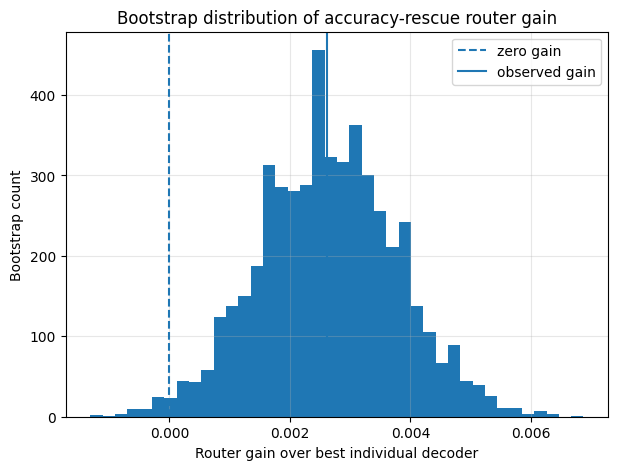

In [52]:
# Section 14: Bootstrap significance of accuracy-rescue router gain

"""
Bootstrap the difference between the learned rescue router and the best fixed decoder.

The bootstrap resamples test examples with replacement. The resulting interval
estimates how stable the router's gain is on this test distribution.
"""

def bootstrap_router_gain(
    baseline_selected,
    router_selected,
    outcome_df,
    decoder_names,
    n_boot=5000,
    seed=SEED,
):
    rng = np.random.default_rng(seed)

    baseline_res = evaluate_router_selection(
        "baseline",
        baseline_selected,
        outcome_df,
        decoder_names,
    )

    router_res = evaluate_router_selection(
        "router",
        router_selected,
        outcome_df,
        decoder_names,
    )

    baseline_correct = baseline_res["chosen_correct"].astype(np.float32)
    router_correct = router_res["chosen_correct"].astype(np.float32)

    diff = router_correct - baseline_correct
    observed_gain = float(diff.mean())

    boot_gains = []
    N = len(diff)

    for _ in range(n_boot):
        idx_boot = rng.integers(0, N, size=N)
        boot_gains.append(float(diff[idx_boot].mean()))

    boot_gains = np.array(boot_gains)

    ci_low, ci_high = np.percentile(boot_gains, [2.5, 97.5])
    p_gain_positive = float((boot_gains > 0).mean())

    return {
        "observed_gain": observed_gain,
        "ci_low_95": float(ci_low),
        "ci_high_95": float(ci_high),
        "p_gain_positive": p_gain_positive,
        "baseline_accuracy": float(baseline_correct.mean()),
        "router_accuracy": float(router_correct.mean()),
        "n_test": N,
        "boot_gains": boot_gains,
    }


bootstrap_result = bootstrap_router_gain(
    baseline_selected=best_individual_selected,
    router_selected=accuracy_rescue_selected,
    outcome_df=test_outcome_df,
    decoder_names=portfolio.names,
    n_boot=5000,
    seed=SEED,
)

print("\n" + "=" * 80)
print("BOOTSTRAP: ACCURACY-RESCUE ROUTER GAIN")
print("=" * 80)

print(f"Test size                    : {bootstrap_result['n_test']}")
print(f"Baseline accuracy            : {bootstrap_result['baseline_accuracy']:.6f}")
print(f"Router accuracy              : {bootstrap_result['router_accuracy']:.6f}")
print(f"Observed gain                : {bootstrap_result['observed_gain']:+.6f}")
print(f"95% bootstrap CI             : [{bootstrap_result['ci_low_95']:+.6f}, {bootstrap_result['ci_high_95']:+.6f}]")
print(f"P(gain > 0)                  : {bootstrap_result['p_gain_positive']:.4f}")

plt.figure(figsize=(7, 5))
plt.hist(bootstrap_result["boot_gains"], bins=40)
plt.axvline(0.0, linestyle="--", label="zero gain")
plt.axvline(bootstrap_result["observed_gain"], linestyle="-", label="observed gain")
plt.xlabel("Router gain over best individual decoder")
plt.ylabel("Bootstrap count")
plt.title("Bootstrap distribution of accuracy-rescue router gain")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [53]:
# Section 15: Save clean results

"""
Save the main tables and a compact JSON summary.

These files let us compare different seeds or different dataset sizes later
without rerunning the entire notebook.
"""

test_metrics_df.to_csv(TABLE_DIR / "decoder_metrics_test.csv", index=False)
train_outcome_df.to_csv(TABLE_DIR / "outcome_train.csv", index=False)
val_outcome_df.to_csv(TABLE_DIR / "outcome_val.csv", index=False)
test_outcome_df.to_csv(TABLE_DIR / "outcome_test.csv", index=False)
final_comparison_df.to_csv(TABLE_DIR / "final_router_comparison.csv", index=False)
comp_df.to_csv(TABLE_DIR / "pairwise_complementarity.csv", index=False)

if getattr(accuracy_rescue_router, "validation_table", None) is not None:
    accuracy_rescue_router.validation_table.to_csv(
        TABLE_DIR / "accuracy_rescue_validation_table.csv",
        index=False,
    )

rescue_summary_df.to_csv(TABLE_DIR / "accuracy_rescue_switch_summary.csv", index=False)
rescue_by_candidate_df.to_csv(TABLE_DIR / "accuracy_rescue_switch_by_candidate.csv", index=False)

payload = {
    "config": CONFIG,
    "best_individual_decoder": best_individual_name,
    "best_individual_accuracy": best_individual_acc,
    "oracle_accuracy": oracle_accuracy_result["accuracy"],
    "accuracy_rescue_router_accuracy": accuracy_rescue_result["accuracy"],
    "accuracy_rescue_gain": accuracy_rescue_result["accuracy"] - best_individual_acc,
    "bootstrap": {k: v for k, v in bootstrap_result.items() if k != "boot_gains"},
    "accuracy_rescue_selected_thresholds": accuracy_rescue_router.selected_thresholds,
}

with open(RESULTS_DIR / "clean_experiment_summary.json", "w") as f:
    json.dump(payload, f, indent=2)

print("Saved clean results under:", RESULTS_DIR.resolve())


Saved clean results under: /content/meta_decoder_results_structured_clean


In [54]:
# Section 16: 3-4 hour scaling config template
# Details: Use this only after a short run shows a learned router beating the best fixed decoder.

print("Scaling guide:")
print("1. First confirm Section 13 shows a learned router above the best individual baseline.")
print("2. Then increase DATASET_SIZE to 40000 or 60000 in Section 1.")
print("3. Optionally use CODE_DISTANCE = 9 and NUM_ROUNDS = 7 once the d=7 benchmark is stable.")
print("4. Keep FORCE_REGENERATE_DATASET = True for a new benchmark version.")
print("5. Compare Section 13 and Section 14 bootstrap before claiming a result.")


Scaling guide:
1. First confirm Section 13 shows a learned router above the best individual baseline.
2. Then increase DATASET_SIZE to 40000 or 60000 in Section 1.
3. Optionally use CODE_DISTANCE = 9 and NUM_ROUNDS = 7 once the d=7 benchmark is stable.
4. Keep FORCE_REGENERATE_DATASET = True for a new benchmark version.
5. Compare Section 13 and Section 14 bootstrap before claiming a result.



Switch summary:


,baseline_decoder,baseline_accuracy,router_accuracy,gain_over_baseline,switch_fraction,helpful_switch_fraction,harmful_switch_fraction,neutral_correct_switch_fraction,neutral_wrong_switch_fraction,net_switch_gain,helpful_switch_count,harmful_switch_count,total_switch_count,n_test
0,cnn_neural_decoder,0.762687,0.765312,0.002625,0.021,0.011813,0.009187,0.0,0.0,0.002625,189,147,336,16000



Switch breakdown by candidate decoder:


,candidate_decoder,switch_fraction,switch_count,helpful_switch_fraction,harmful_switch_fraction,neutral_correct_switch_fraction,neutral_wrong_switch_fraction,helpful_switch_count,harmful_switch_count,net_gain_from_candidate
4,mlp_neural_decoder,0.013813,221,0.008000,0.005812,0.0,0.0,128,93,0.002188
1,mwpm_like_repetition,0.000375,6,0.000313,0.000063,0.0,0.0,5,1,0.000250
3,empirical_mld_small,0.004313,69,0.002250,0.002063,0.0,0.0,36,33,0.000187
2,union_find_proxy,0.002125,34,0.001125,0.001000,0.0,0.0,18,16,0.000125
0,cheap_heuristic,0.000375,6,0.000125,0.000250,0.0,0.0,2,4,-0.000125



Chosen decoder fractions:


,router,cheap_heuristic,mwpm_like_repetition,union_find_proxy,empirical_mld_small,mlp_neural_decoder,cnn_neural_decoder
0,accuracy_rescue_gate_router,0.000375,0.000375,0.002125,0.004313,0.013813,0.979


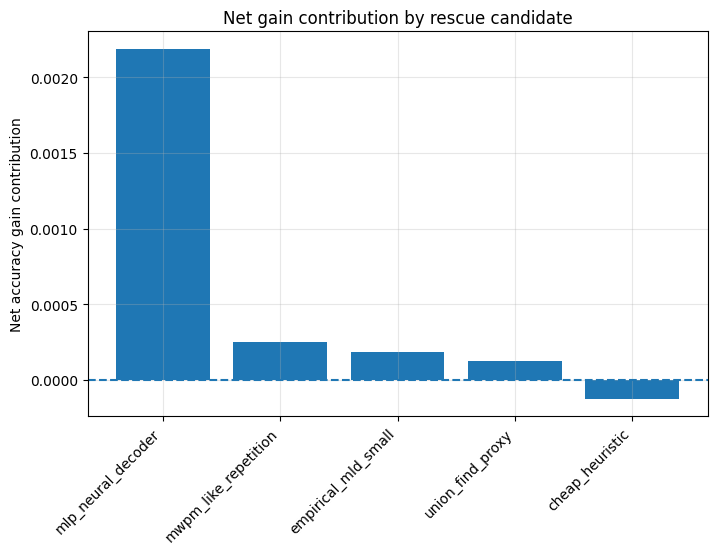

In [55]:
# Section 17: Detailed accuracy-rescue switch diagnostics

"""
This section explains how the learned rescue router improved over the best
individual decoder.

The important quantities are:

    helpful switch:
        baseline decoder is wrong, routed decoder is correct

    harmful switch:
        baseline decoder is correct, routed decoder is wrong

    net switch gain:
        helpful switch fraction - harmful switch fraction

The final accuracy gain is exactly the net switch gain.
"""

baseline_name = best_individual_name
baseline_idx = best_individual_idx

baseline_correct = test_outcome_df[
    f"{baseline_name}__correct"
].values.astype(np.int64)

router_result = evaluate_router_selection(
    "accuracy_rescue_gate_router",
    accuracy_rescue_selected,
    test_outcome_df,
    portfolio.names,
)

router_correct = router_result["chosen_correct"].astype(np.int64)

switched = accuracy_rescue_selected != baseline_idx

helpful = switched & (baseline_correct == 0) & (router_correct == 1)
harmful = switched & (baseline_correct == 1) & (router_correct == 0)
neutral_correct = switched & (baseline_correct == 1) & (router_correct == 1)
neutral_wrong = switched & (baseline_correct == 0) & (router_correct == 0)

switch_summary_df = pd.DataFrame([{
    "baseline_decoder": baseline_name,
    "baseline_accuracy": float(baseline_correct.mean()),
    "router_accuracy": float(router_correct.mean()),
    "gain_over_baseline": float(router_correct.mean() - baseline_correct.mean()),
    "switch_fraction": float(switched.mean()),
    "helpful_switch_fraction": float(helpful.mean()),
    "harmful_switch_fraction": float(harmful.mean()),
    "neutral_correct_switch_fraction": float(neutral_correct.mean()),
    "neutral_wrong_switch_fraction": float(neutral_wrong.mean()),
    "net_switch_gain": float(helpful.mean() - harmful.mean()),
    "helpful_switch_count": int(helpful.sum()),
    "harmful_switch_count": int(harmful.sum()),
    "total_switch_count": int(switched.sum()),
    "n_test": len(test_outcome_df),
}])

print("\nSwitch summary:")
display(switch_summary_df)

candidate_rows = []

for j, decoder_name in enumerate(portfolio.names):
    if j == baseline_idx:
        continue

    to_decoder = accuracy_rescue_selected == j

    candidate_rows.append({
        "candidate_decoder": decoder_name,
        "switch_fraction": float(to_decoder.mean()),
        "switch_count": int(to_decoder.sum()),
        "helpful_switch_fraction": float((to_decoder & helpful).mean()),
        "harmful_switch_fraction": float((to_decoder & harmful).mean()),
        "neutral_correct_switch_fraction": float((to_decoder & neutral_correct).mean()),
        "neutral_wrong_switch_fraction": float((to_decoder & neutral_wrong).mean()),
        "helpful_switch_count": int((to_decoder & helpful).sum()),
        "harmful_switch_count": int((to_decoder & harmful).sum()),
        "net_gain_from_candidate": float((to_decoder & helpful).mean() - (to_decoder & harmful).mean()),
    })

candidate_switch_diagnostics_df = pd.DataFrame(candidate_rows).sort_values(
    "net_gain_from_candidate",
    ascending=False,
)

print("\nSwitch breakdown by candidate decoder:")
display(candidate_switch_diagnostics_df)

print("\nChosen decoder fractions:")
chosen_decoder_fraction_df = routing_fraction_table(
    {
        "accuracy_rescue_gate_router": accuracy_rescue_selected,
    },
    portfolio.names,
)

display(chosen_decoder_fraction_df)

plt.figure(figsize=(8, 5))
plt.bar(
    candidate_switch_diagnostics_df["candidate_decoder"],
    candidate_switch_diagnostics_df["net_gain_from_candidate"],
)
plt.axhline(0.0, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Net accuracy gain contribution")
plt.title("Net gain contribution by rescue candidate")
plt.grid(True, alpha=0.3)
plt.show()


Regime-wise rescue diagnostics:


,regime,n_samples,baseline_accuracy,router_accuracy,gain_over_baseline,switch_fraction,helpful_switch_fraction,harmful_switch_fraction,net_switch_gain
2,easy_low_weight,2481,0.907295,0.916566,0.009270,0.017332,0.013301,0.004031,0.009270
4,lookup_pattern,2729,0.866618,0.872847,0.006229,0.031147,0.018688,0.012459,0.006229
3,iid_smooth,2816,0.641335,0.645597,0.004261,0.020597,0.012429,0.008168,0.004261
1,bursty_cluster,2896,0.858771,0.859116,0.000345,0.018301,0.009323,0.008978,0.000345
5,nonlinear_mixed,2707,0.757296,0.756188,-0.001108,0.021057,0.009974,0.011082,-0.001108
0,ambiguous_mixed,2371,0.524673,0.521299,-0.003374,0.016871,0.006748,0.010122,-0.003374



Chosen decoder fractions by regime:


decoder,cheap_heuristic,cnn_neural_decoder,empirical_mld_small,mlp_neural_decoder,mwpm_like_repetition,union_find_proxy
regime,,,,,,
ambiguous_mixed,0.000000,0.983129,0.003374,0.011388,0.000422,0.001687
bursty_cluster,0.000691,0.981699,0.003108,0.012086,0.000000,0.002417
easy_low_weight,0.000403,0.982668,0.004837,0.007255,0.000806,0.004031
iid_smooth,0.000355,0.979403,0.002841,0.017045,0.000000,0.000355
lookup_pattern,0.000000,0.968853,0.008794,0.018322,0.001099,0.002931
nonlinear_mixed,0.000739,0.978943,0.002955,0.015885,0.000000,0.001478


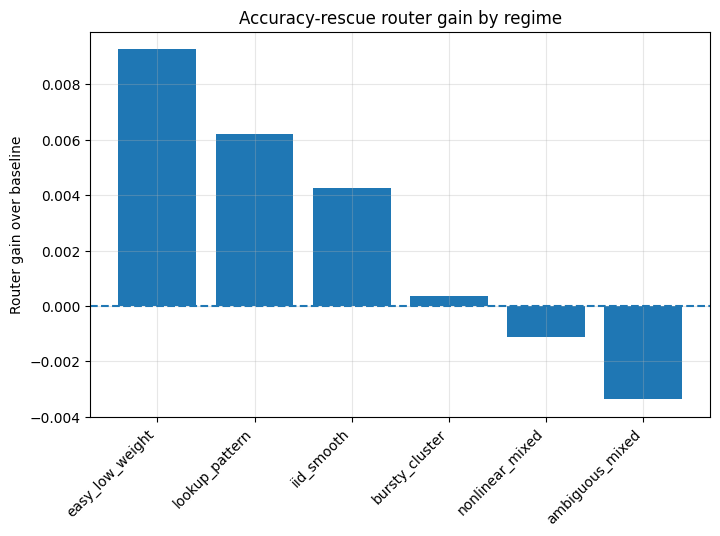

In [56]:
# Section 18: Regime-wise accuracy-rescue diagnostics

"""
This section checks where the router helps.

It groups test samples by the hidden benchmark regime and asks:

    Where does the baseline fail?
    Where does the rescue router improve?
    Which candidate decoders are selected in each regime?

This is diagnostic only. The router itself does not use the true regime label.
"""

test_meta = meta_df.iloc[test_idx].reset_index(drop=True).copy()

regime_rows = []

for regime, idxs in test_meta.groupby("regime").groups.items():
    idxs = np.array(list(idxs), dtype=np.int64)

    baseline_acc_regime = float(baseline_correct[idxs].mean())
    router_acc_regime = float(router_correct[idxs].mean())

    switched_regime = switched[idxs]
    helpful_regime = helpful[idxs]
    harmful_regime = harmful[idxs]

    regime_rows.append({
        "regime": regime,
        "n_samples": int(len(idxs)),
        "baseline_accuracy": baseline_acc_regime,
        "router_accuracy": router_acc_regime,
        "gain_over_baseline": router_acc_regime - baseline_acc_regime,
        "switch_fraction": float(switched_regime.mean()),
        "helpful_switch_fraction": float(helpful_regime.mean()),
        "harmful_switch_fraction": float(harmful_regime.mean()),
        "net_switch_gain": float(helpful_regime.mean() - harmful_regime.mean()),
    })

regime_diagnostics_df = pd.DataFrame(regime_rows).sort_values(
    "gain_over_baseline",
    ascending=False,
)

print("\nRegime-wise rescue diagnostics:")
display(regime_diagnostics_df)

regime_candidate_rows = []

for regime, idxs in test_meta.groupby("regime").groups.items():
    idxs = np.array(list(idxs), dtype=np.int64)

    for j, decoder_name in enumerate(portfolio.names):
        selected_j = accuracy_rescue_selected[idxs] == j

        regime_candidate_rows.append({
            "regime": regime,
            "decoder": decoder_name,
            "chosen_fraction": float(selected_j.mean()),
            "chosen_count": int(selected_j.sum()),
        })

regime_candidate_fraction_df = pd.DataFrame(regime_candidate_rows)

print("\nChosen decoder fractions by regime:")
display(
    regime_candidate_fraction_df.pivot(
        index="regime",
        columns="decoder",
        values="chosen_fraction",
    ).fillna(0.0)
)

plt.figure(figsize=(8, 5))
plt.bar(
    regime_diagnostics_df["regime"],
    regime_diagnostics_df["gain_over_baseline"],
)
plt.axhline(0.0, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Router gain over baseline")
plt.title("Accuracy-rescue router gain by regime")
plt.grid(True, alpha=0.3)
plt.show()

In [57]:
# Section 19: Save final diagnostic tables

"""
This section saves the important tables from the successful run.

These files will be useful later for:
    report writing
    plotting
    GitHub repository organization
    comparing future seeds/runs
"""

final_run_summary = {
    "best_individual_decoder": best_individual_name,
    "best_individual_accuracy": float(best_individual_acc),
    "oracle_accuracy": float(oracle_accuracy_result["accuracy"]),
    "accuracy_rescue_router_accuracy": float(accuracy_rescue_result["accuracy"]),
    "accuracy_rescue_gain": float(accuracy_rescue_result["accuracy"] - best_individual_acc),
    "bootstrap_observed_gain": float(bootstrap_result["observed_gain"]),
    "bootstrap_ci_low_95": float(bootstrap_result["ci_low_95"]),
    "bootstrap_ci_high_95": float(bootstrap_result["ci_high_95"]),
    "bootstrap_p_gain_positive": float(bootstrap_result["p_gain_positive"]),
    "n_test": int(bootstrap_result["n_test"]),
}

final_run_summary_df = pd.DataFrame([final_run_summary])

display(final_run_summary_df)

final_run_summary_df.to_csv(
    TABLE_DIR / "final_accuracy_rescue_summary.csv",
    index=False,
)

switch_summary_df.to_csv(
    TABLE_DIR / "accuracy_rescue_switch_summary.csv",
    index=False,
)

candidate_switch_diagnostics_df.to_csv(
    TABLE_DIR / "accuracy_rescue_candidate_breakdown.csv",
    index=False,
)

regime_diagnostics_df.to_csv(
    TABLE_DIR / "accuracy_rescue_regime_breakdown.csv",
    index=False,
)

regime_candidate_fraction_df.to_csv(
    TABLE_DIR / "accuracy_rescue_regime_candidate_fractions.csv",
    index=False,
)

if accuracy_rescue_router.validation_table is not None:
    accuracy_rescue_router.validation_table.to_csv(
        TABLE_DIR / "accuracy_rescue_threshold_tuning_table.csv",
        index=False,
    )

with open(RESULTS_DIR / "final_accuracy_rescue_summary.json", "w") as f:
    json.dump(final_run_summary, f, indent=2)

print("Saved final diagnostic tables to:", TABLE_DIR)
print("Saved final summary JSON to:", RESULTS_DIR / "final_accuracy_rescue_summary.json")

,best_individual_decoder,best_individual_accuracy,oracle_accuracy,accuracy_rescue_router_accuracy,accuracy_rescue_gain,bootstrap_observed_gain,bootstrap_ci_low_95,bootstrap_ci_high_95,bootstrap_p_gain_positive,n_test
0,cnn_neural_decoder,0.762687,0.995875,0.765312,0.002625,0.002625,0.000375,0.004938,0.9864,16000


Saved final diagnostic tables to: meta_decoder_results_structured_clean/tables
Saved final summary JSON to: meta_decoder_results_structured_clean/final_accuracy_rescue_summary.json


In [58]:
# Section 20: Final ablations and sanity checks

"""
This section checks whether the final learned-router gain is meaningful.

Main questions:
    1. Is the gain mostly coming from the MLP rescue gate?
    2. Does the learned router beat a random switch policy with the same switch rate?
    3. How much of the oracle gap does the learned router recover?

This section does not retrain the decoders.
It uses the already-trained accuracy_rescue_router from Section 12.
"""


def evaluate_selected_router(router_name, selected):
    return evaluate_router_selection(
        router_name,
        selected,
        test_outcome_df,
        portfolio.names,
    )


def make_single_candidate_selection(candidate_name):
    """
    Reuse the trained accuracy_rescue_router, but allow only one candidate
    decoder to override the baseline.
    """

    selected = np.full(
        len(test_outcome_df),
        best_individual_idx,
        dtype=np.int64,
    )

    if candidate_name not in accuracy_rescue_router.selected_thresholds:
        return selected

    scores = accuracy_rescue_router.candidate_scores(
        X[test_idx],
        test_outcome_df,
    )

    local_j = accuracy_rescue_router.candidate_decoder_names.index(candidate_name)
    global_j = portfolio.names.index(candidate_name)

    threshold = accuracy_rescue_router.selected_thresholds[candidate_name]

    switch = scores[:, local_j] >= threshold
    selected[switch] = global_j

    return selected


def make_random_switch_selection(reference_selected, seed=SEED):
    """
    Random-switch baseline.

    It switches away from the best decoder at the same overall switch fraction
    as the learned rescue router, but chooses random samples and random
    non-baseline decoders.

    This tests whether the learned switch locations matter.
    """

    rng = np.random.default_rng(seed)

    learned_switch = reference_selected != best_individual_idx
    switch_count = int(learned_switch.sum())

    selected = np.full(
        len(reference_selected),
        best_individual_idx,
        dtype=np.int64,
    )

    if switch_count == 0:
        return selected

    switch_indices = rng.choice(
        len(reference_selected),
        size=switch_count,
        replace=False,
    )

    candidate_indices = [
        i for i, name in enumerate(portfolio.names)
        if i != best_individual_idx
    ]

    random_choices = rng.choice(
        candidate_indices,
        size=switch_count,
        replace=True,
    )

    selected[switch_indices] = random_choices

    return selected


# Baseline selections
oracle_selected_ablation = oracle_accuracy_selected

best_individual_selected_ablation = np.full(
    len(test_outcome_df),
    best_individual_idx,
    dtype=np.int64,
)

full_rescue_selected_ablation = accuracy_rescue_selected

# Single-candidate rescue selections
single_candidate_selections = {}

for candidate_name in accuracy_rescue_router.candidate_decoder_names:
    single_candidate_selections[f"{candidate_name}_only_rescue"] = make_single_candidate_selection(
        candidate_name
    )

# Random-switch controls
random_switch_rows = []

for random_seed in range(SEED, SEED + 10):
    random_selected = make_random_switch_selection(
        full_rescue_selected_ablation,
        seed=random_seed,
    )

    random_result = evaluate_selected_router(
        f"random_switch_seed_{random_seed}",
        random_selected,
    )

    random_switch_rows.append({
        "seed": random_seed,
        "accuracy": random_result["accuracy"],
        "gain_over_baseline": random_result["accuracy"] - best_individual_acc,
        "switch_fraction": float((random_selected != best_individual_idx).mean()),
    })

random_switch_df = pd.DataFrame(random_switch_rows)

# Main ablation table
ablation_selection_dict = {
    "oracle_accuracy_router": oracle_selected_ablation,
    "best_individual_baseline": best_individual_selected_ablation,
    "full_accuracy_rescue_router": full_rescue_selected_ablation,
}

ablation_selection_dict.update(single_candidate_selections)

ablation_rows = []

for router_name, selected in ablation_selection_dict.items():
    result = evaluate_selected_router(router_name, selected)

    switched = selected != best_individual_idx

    ablation_rows.append({
        "router": router_name,
        "accuracy": result["accuracy"],
        "gain_over_baseline": result["accuracy"] - best_individual_acc,
        "switch_fraction": float(switched.mean()),
        "avg_compute": result["avg_compute"],
        "avg_runtime_sec": result["avg_runtime_sec"],
    })

ablation_df = pd.DataFrame(ablation_rows).sort_values(
    ["accuracy", "avg_compute"],
    ascending=[False, True],
)

print("\nFinal ablation table:")
display(ablation_df)

print("\nRandom-switch control summary:")
display(random_switch_df.describe())

print("\nRandom-switch control runs:")
display(random_switch_df)

# Compare learned router against random switching
learned_gain = float(
    ablation_df[
        ablation_df["router"] == "full_accuracy_rescue_router"
    ]["gain_over_baseline"].iloc[0]
)

random_mean_gain = float(random_switch_df["gain_over_baseline"].mean())
random_best_gain = float(random_switch_df["gain_over_baseline"].max())

print("\n" + "=" * 80)
print("FINAL ABLATION INTERPRETATION")
print("=" * 80)

print(f"Best individual decoder          : {best_individual_name}")
print(f"Best individual accuracy         : {best_individual_acc:.6f}")
print(f"Full rescue-router accuracy      : {accuracy_rescue_result['accuracy']:.6f}")
print(f"Full rescue-router gain          : {learned_gain:+.6f}")
print(f"Mean random-switch gain          : {random_mean_gain:+.6f}")
print(f"Best random-switch gain          : {random_best_gain:+.6f}")
print(f"Oracle accuracy                  : {oracle_accuracy_result['accuracy']:.6f}")
print(f"Oracle gap over baseline         : {oracle_accuracy_result['accuracy'] - best_individual_acc:+.6f}")
print(f"Recovered oracle gap fraction    : {learned_gain / max(1e-12, oracle_accuracy_result['accuracy'] - best_individual_acc):.4f}")

if learned_gain > random_best_gain:
    print("\nThe learned router beats all random-switch controls.")
else:
    print("\nThe learned router does not beat every random-switch control, but compare against the random mean and bootstrap CI.")

# Save ablation outputs
ablation_df.to_csv(
    TABLE_DIR / "final_ablation_table.csv",
    index=False,
)

random_switch_df.to_csv(
    TABLE_DIR / "random_switch_control_table.csv",
    index=False,
)

print("\nSaved ablation tables to:", TABLE_DIR)


Final ablation table:


,router,accuracy,gain_over_baseline,switch_fraction,avg_compute,avg_runtime_sec
0,oracle_accuracy_router,0.995875,0.233187,0.999812,3.040437,0.000085
7,mlp_neural_decoder_only_rescue,0.765875,0.003188,0.019563,5.480437,0.000066
2,full_accuracy_rescue_router,0.765312,0.002625,0.021000,5.499844,0.000068
4,mwpm_like_repetition_only_rescue,0.764000,0.001313,0.001687,5.500844,0.000068
6,empirical_mld_small_only_rescue,0.763938,0.001250,0.005875,5.526437,0.000069
3,cheap_heuristic_only_rescue,0.763813,0.001125,0.002250,5.489875,0.000067
5,union_find_proxy_only_rescue,0.763500,0.000812,0.003812,5.492375,0.000068
1,best_individual_baseline,0.762687,0.000000,0.000000,5.500000,0.000068



Random-switch control summary:


,seed,accuracy,gain_over_baseline,switch_fraction
count,10.00000,10.000000,10.000000,1.000000e+01
mean,11.50000,0.759563,-0.003125,2.100000e-02
std,3.02765,0.000427,0.000427,3.657118e-18
min,7.00000,0.758625,-0.004062,2.100000e-02
25%,9.25000,0.759406,-0.003281,2.100000e-02
50%,11.50000,0.759594,-0.003094,2.100000e-02
75%,13.75000,0.759797,-0.002891,2.100000e-02
max,16.00000,0.760125,-0.002562,2.100000e-02



Random-switch control runs:


,seed,accuracy,gain_over_baseline,switch_fraction
0,7,0.759500,-0.003188,0.021
1,8,0.759687,-0.003000,0.021
2,9,0.759500,-0.003188,0.021
3,10,0.760000,-0.002687,0.021
4,11,0.759375,-0.003312,0.021
5,12,0.759750,-0.002937,0.021
6,13,0.759250,-0.003437,0.021
7,14,0.758625,-0.004062,0.021
8,15,0.760125,-0.002562,0.021
9,16,0.759813,-0.002875,0.021



FINAL ABLATION INTERPRETATION
Best individual decoder          : cnn_neural_decoder
Best individual accuracy         : 0.762687
Full rescue-router accuracy      : 0.765312
Full rescue-router gain          : +0.002625
Mean random-switch gain          : -0.003125
Best random-switch gain          : -0.002562
Oracle accuracy                  : 0.995875
Oracle gap over baseline         : +0.233187
Recovered oracle gap fraction    : 0.0113

The learned router beats all random-switch controls.

Saved ablation tables to: meta_decoder_results_structured_clean/tables
